# LASSO Regression


## How to use this notebook

Run the cells sequentially. Several later sections reuse variables created earlier, especially `df`, `X`, `y`, `feature_names`, `scaler`, `output_folder`, and fitted model objects.


## Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    LeaveOneGroupOut,
)
from sklearn.linear_model import LassoCV, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
import time
import os
from pathlib import Path


## Matplotlib settings

In [9]:
import matplotlib as mpl
from matplotlib.lines import Line2D

mpl.rcParams.update(
    {
        # Font
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 8,  # good for 1-column journal figures
        # Axes
        "axes.linewidth": 0.8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        # Ticks
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        # Legend
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "legend.frameon": False,
        # Lines
        "lines.linewidth": 1.2,
        "lines.markersize": 7,
        # Savefig
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }
)


## Read in Data

Input df:


,cat_substrate,ddG,x1,x2,x4,x5,x6,x7,x8,x9,...,x22,x23,x24,x25,x26,x27,x28,x29,x30,x24subx11_squared
0,KA2_A1,1.719047,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,65.001117,65.001117,61.135839,52.712682,-0.174130,0.014710,-0.312250,-0.112310,75.879021,326.463617
1,KA2_A2,1.618875,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,65.052418,64.979701,61.170292,52.685893,-0.174002,0.014858,-0.311965,-0.111760,75.971806,325.219781
2,KA2_A3,0.850944,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,65.483210,65.159416,61.079038,52.740635,-0.172925,0.015287,-0.305578,-0.112397,77.051048,328.519448
3,KA2_A4,1.770180,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,65.021364,64.961077,61.243854,52.719670,-0.177385,0.012581,-0.319768,-0.097328,76.032035,322.571971
4,KA2_A5,0.955859,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,...,68.966344,68.952063,74.154499,57.367569,-0.169511,0.018550,-0.109682,-0.143138,77.845423,25.498900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,KA19_A11,2.038309,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,...,65.130180,65.117513,61.165636,52.777325,-0.180313,0.000218,-0.277837,-0.134138,76.126449,989.564421
142,KA19_A13,1.897460,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,...,65.249460,64.802779,61.135839,52.754612,-0.173615,-0.003854,-0.295268,-0.118832,76.417828,991.440002
143,KA19_A14,1.369995,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,...,65.499763,65.493705,61.268996,55.992010,-0.172548,-0.007086,-0.285723,-0.134123,76.473174,983.072264
144,KA19_A19,1.913457,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,...,71.598866,71.584476,66.789891,70.284546,-0.173572,0.012529,-0.301668,0.018862,80.156921,667.348426


Using identifier column: cat_substrate
Removed columns: 0 []



,cat_substrate,x1,x2,x4,x5,x6,x7,x8,x9,x11,...,x22,x23,x24,x25,x26,x27,x28,x29,x30,x24subx11_squared
0,KA2_A1,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,79.204143,...,65.001117,65.001117,61.135839,52.712682,-0.174130,0.014710,-0.312250,-0.112310,75.879021,326.463617
1,KA2_A2,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,79.204143,...,65.052418,64.979701,61.170292,52.685893,-0.174002,0.014858,-0.311965,-0.111760,75.971806,325.219781
2,KA2_A3,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,79.204143,...,65.483210,65.159416,61.079038,52.740635,-0.172925,0.015287,-0.305578,-0.112397,77.051048,328.519448
3,KA2_A4,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,79.204143,...,65.021364,64.961077,61.243854,52.719670,-0.177385,0.012581,-0.319768,-0.097328,76.032035,322.571971
4,KA2_A5,80.570247,72.976572,0.32688,-0.398047,-0.798253,78.523006,54.199568,63.825052,79.204143,...,68.966344,68.952063,74.154499,57.367569,-0.169511,0.018550,-0.109682,-0.143138,77.845423,25.498900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,KA19_A11,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,92.622979,...,65.130180,65.117513,61.165636,52.777325,-0.180313,0.000218,-0.277837,-0.134138,76.126449,989.564421
142,KA19_A13,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,92.622979,...,65.249460,64.802779,61.135839,52.754612,-0.173615,-0.003854,-0.295268,-0.118832,76.417828,991.440002
143,KA19_A14,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,92.622979,...,65.499763,65.493705,61.268996,55.992010,-0.172548,-0.007086,-0.285723,-0.134123,76.473174,983.072264
144,KA19_A19,78.211599,68.182919,0.31718,-0.373517,-0.802940,90.370012,63.488900,66.403457,92.622979,...,71.598866,71.584476,66.789891,70.284546,-0.173572,0.012529,-0.301668,0.018862,80.156921,667.348426


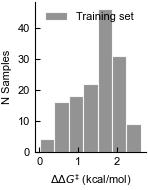

Training Set Size: 146
(146, 29)


In [10]:
# ---- 1. Load your data ----
input_folder = ""
input_file = "training_set_base_plus_int.csv"
output_folder = "results/"
os.makedirs(output_folder, exist_ok=True)
df = pd.read_csv(input_folder + input_file)
print("Input df:")
display(df)

# Determine identifier column (new files use cat_substrate as first column)
id_col = "cat_substrate" if "cat_substrate" in df.columns else df.columns[0]
print(f"Using identifier column: {id_col}")

# ---- Built features and response arrays ------
df_clean = df.drop(columns=[id_col])  # drop identifier column
# ---- Remove columns that have too big parameters (important for SISSO features, because they break over 10^6)
# Define your threshold
upper_threshold = 1e6  # change to whatever "too big" means for your case
lower_threshold = (
    1e-6  # if you also want to remove too small values, define a lower threshold
)
# Identify columns where any value is above the threshold
cols_too_big = df_clean.columns[(df_clean.abs() >= upper_threshold).any()]
# Identify columns where any value is below the lower threshold
cols_too_small = df_clean.columns[(df_clean.abs() < lower_threshold).all()]
# Combine both sets of columns to remove
cols_to_remove = cols_too_big.union(cols_too_small)
# Drop them
df_clean = df_clean.drop(columns=cols_to_remove)
print(f"Removed columns: {len(cols_to_remove)} {list(cols_to_remove)}\n")
feature_df = df.drop(columns=["ddG"])
display(feature_df)
base_df = df.filter(regex=r"^x\d+$")

X = df_clean.drop(columns=["ddG"]).values
x_base = base_df.values
y = df_clean["ddG"].values
feature_names = df_clean.columns[1:]
base_feature_names = base_df.columns[0:]

scaler = StandardScaler()  # Setting up the default scaler for later

# Plot training-set target distribution in the same clean style as the other figures
plt.figure(figsize=(1.68, 2.1))

bin_edges = np.linspace(
    y.min(), y.max(), 8
)
plt.hist(
    y,
    bins=bin_edges,
    alpha=0.85,
    color="grey",
    edgecolor="white",
    linewidth=0.8,
    label="Training set",
)

plt.xlabel(r"$\Delta\Delta G^{\ddagger}$ (kcal/mol)")
plt.ylabel("N Samples")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()

histogram_png = os.path.join(output_folder, "histogram_static.png")
histogram_pdf = os.path.splitext(histogram_png)[0] + ".pdf"
plt.savefig(histogram_png, dpi=300, bbox_inches="tight")
plt.savefig(histogram_pdf, bbox_inches="tight")
plt.show()

print("Training Set Size:", len(y))

results = {}
predictions = {}


# ---- 2. Helper functions to compute metrics ----
def compute_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    return {
        "Train R2": r2_score(y_train, y_train_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
    }


def external_test_metrics(model, x_external, y_external):
    y_external_pred = model.predict(x_external)
    return {
        "External R2": r2_score(y_external, y_external_pred),
        "External MSE": mean_squared_error(y_external, y_external_pred),
        "External MAE": mean_absolute_error(y_external, y_external_pred),
        "y_external_pred": y_external_pred,
    }


def show_parameters(df1, df2):
    matches = []
    # iterate over each "name" from df2 first column
    for name in df2.iloc[:, 0]:
        # check for matches in the *first column of feature_df*
        matches_x = df1[df1.iloc[:, 0].str.fullmatch(name, case=False, na=False)]
        if not matches_x.empty:
            matches.append(matches_x)

    if matches:
        param_contr_df = pd.concat(matches, axis=0)  # stack rows
        display(param_contr_df)
        # return param_contr_df
    else:
        print("No matches found.")
        return None


def external_r2(y_test_measured, y_test_predicted, y_train):
    """Calculates the external R2 pred as described:
    https://pdfs.semanticscholar.org/4eb2/5ff5a87f2fd6789c5b9954eddddfd1c59dab.pdf
    That is actually really important for e.g. LOGO analysis. Otherwise the normal R^2 will just give the comparison to the external test set mean,
    but we are already happy if the mean of a group or whatever is predicted accurately and not about the statistics of the test set itself!"""

    y_residual = y_test_predicted - y_test_measured
    SS_residual = np.sum(y_residual**2)
    y_varience = y_test_measured - np.mean(y_train)
    SS_total = np.sum(y_varience**2)
    r2_validation = 1 - SS_residual / SS_total
    return r2_validation


print(X.shape)


## Nested Cross Validation 

### Leave One Group Out Validation

In [ ]:
# Use this paragraph if we want to do a LOGO analysis----------------------------
which_logo = "substrate"  # choose between catalyst and substrate
logo = LeaveOneGroupOut()
logo_df = df
new_cols = logo_df["cat_substrate"].str.split("_", expand=True)
new_cols = new_cols.set_axis(["catalyst", "substrate"], axis=1)
# logo_df = pd.concat([base_df, new_cols], axis=1)                       #for base feature modeling
logo_df = pd.concat([df_clean, new_cols], axis=1)
groups = logo_df[which_logo].values
print(f"Groups ({len(np.unique(groups))} total): {np.unique(groups)}\n")
parameters_df = logo_df.drop(["ddG"], axis=1)
# parameters_df = logo_df                                                 #for base feature modeling
response_df = logo_df["ddG"].values
# response_df = df["ddG"].values                                          #for base feature modeling


def external_r2(y_test_measured, y_test_predicted, y_train):
    """Calculates the external R2 pred as described:
    https://pdfs.semanticscholar.org/4eb2/5ff5a87f2fd6789c5b9954eddddfd1c59dab.pdf
    That is actually really important for e.g. LOGO analysis. Otherwise the normal R^2 will just give the comparison to the external test set mean,
    but we are already happy if the mean of a group or whatever is predicted accurately and not about the statistics of the test set itself!"""

    y_residual = y_test_predicted - y_test_measured
    SS_residual = np.sum(y_residual**2)
    y_varience = y_test_measured - np.mean(y_train)
    SS_total = np.sum(y_varience**2)
    r2_validation = 1 - SS_residual / SS_total
    return r2_validation


for i, (train_idx, test_idx) in enumerate(
    logo.split(parameters_df, response_df, groups)
):
    test_group = groups[test_idx][0]
    print("Iteration", i)
    print("Left Out Group:", test_group)
    # Create train/test subsets
    X_logo_train, X_logo_test = (
        parameters_df.iloc[train_idx],
        parameters_df.iloc[test_idx],
    )
    y_logo_train, y_logo_test = response_df[train_idx], response_df[test_idx]

    plt.figure(figsize=(6, 5))

    plt.hist(y_logo_train, bins=8, alpha=0.7, label="Train", edgecolor="black")
    plt.hist(y_logo_test, bins=6, alpha=0.7, label="Test", edgecolor="black")

    plt.xlabel("ddG")
    plt.ylabel("Frequency")
    plt.title("Distribution of ddG in Fold")
    plt.legend()
    plt.show()

    print("Training Set Size:", len(y_logo_train))
    print("Training Set Mean:", np.mean(y_logo_train))
    print("Test Set Size:", len(y_logo_test))
    print("Test Set Mean:", np.mean(y_logo_test))
    print("Test/Train Ratio:", np.round(len(y_logo_test) / len(y_logo_train), 2))
    print("\n\n")

# print(groups)
# --------------------------------------------------------------------------------


### LOGO LASSO

In [ ]:
# ---- 3. Lasso ----

# Choose LOGO prediction alpha:
# "1se" -> use alpha_1se model (sparser)
# "min" -> use alpha_min from LassoCV (best CV MSE)
logo_alpha_choice = "1se"  # change to "min" if needed

# Choose inner CV for LOGO LASSO:
# "repeated_stratified_kfold" -> stratified on binned y per LOGO training fold
# "repeated_kfold" -> plain repeated K-fold
inner_cv_strategy = "repeated_kfold"
inner_cv_n_splits = 5
inner_cv_n_repeats = 4
inner_cv_random_state = 42
inner_cv_n_bins = 5

if inner_cv_strategy == "repeated_stratified_kfold":
    inner_cv = RepeatedStratifiedKFold(
        n_splits=inner_cv_n_splits,
        n_repeats=inner_cv_n_repeats,
        random_state=inner_cv_random_state,
    )
elif inner_cv_strategy == "repeated_kfold":
    inner_cv = RepeatedKFold(
        n_splits=inner_cv_n_splits,
        n_repeats=inner_cv_n_repeats,
        random_state=inner_cv_random_state,
    )
else:
    raise ValueError(
        "inner_cv_strategy must be 'repeated_stratified_kfold' or 'repeated_kfold'."
    )

# LOGO metadata for export
inner_cv_method = type(inner_cv).__name__

# --- Storage ---
train_r2_list, test_r2_list, ext_test_r2_list = [], [], []
train_mae_list, test_mae_list = [], []
train_mse_list, test_mse_list = [], []
alphas_chosen, intercepts_list = [], []
coefs_list = []

# Per-left-out-group summary + test-only predictions for final parity plot
logo_group_results = []
logo_test_predictions = []

for i, (train_idx, test_idx) in enumerate(
    logo.split(parameters_df, response_df, groups)
):
    test_group = groups[test_idx][0]

    # Create train/test subsets
    X_train_outer, X_test_outer = (
        parameters_df.iloc[train_idx],
        parameters_df.iloc[test_idx],
    )
    y_train_outer, y_test_outer = response_df[train_idx], response_df[test_idx]
    X_train_outer = X_train_outer.drop(["catalyst", "substrate"], axis=1)
    X_test_outer = X_test_outer.drop(["catalyst", "substrate"], axis=1)

    # Scale features
    X_train_scaled = scaler.fit_transform(X_train_outer)
    X_test_scaled = scaler.transform(X_test_outer)

    # Inner CV split strategy
    cv_for_fold = inner_cv
    y_for_cv = y_train_outer
    cv_note = None

    if inner_cv_strategy == "repeated_stratified_kfold":
        y_train_outer_binned = pd.qcut(
            y_train_outer, q=inner_cv_n_bins, labels=False, duplicates="drop"
        )
        bin_counts = pd.Series(y_train_outer_binned).value_counts()
        min_bin_count = int(bin_counts.min()) if len(bin_counts) > 0 else 0
        effective_splits = min(inner_cv_n_splits, min_bin_count)

        if effective_splits >= 2 and len(bin_counts) >= 2:
            cv_for_fold = RepeatedStratifiedKFold(
                n_splits=effective_splits,
                n_repeats=inner_cv_n_repeats,
                random_state=inner_cv_random_state,
            )
            y_for_cv = y_train_outer_binned
            if effective_splits != inner_cv_n_splits:
                cv_note = f"n_splits reduced to {effective_splits} (smallest bin size)."
        else:
            cv_for_fold = RepeatedKFold(
                n_splits=inner_cv_n_splits,
                n_repeats=inner_cv_n_repeats,
                random_state=inner_cv_random_state,
            )
            y_for_cv = y_train_outer
            cv_note = (
                "fallback to RepeatedKFold (insufficient stratification bins in fold)."
            )

    # Inner CV
    lasso = LassoCV(
        cv=cv_for_fold.split(X_train_scaled, y_for_cv),
        random_state=42,
        max_iter=100000,
        n_jobs=-1,
    ).fit(X_train_scaled, y_train_outer)

    # Validation curve data
    alphas_cv = lasso.alphas_
    val_mse = np.mean(lasso.mse_path_, axis=1)

    # Training MSE for each alpha
    train_mse = []
    for a in alphas_cv:
        lasso_cv = Lasso(alpha=a, max_iter=100000)
        lasso_cv.fit(X_train_scaled, y_train_outer)
        y_pred = lasso_cv.predict(X_train_scaled)
        mse = mean_squared_error(y_train_outer, y_pred)
        train_mse.append(mse)

    # Calculate 1-SE alpha
    std_mse = np.std(lasso.mse_path_, axis=1)
    n_splits = cv_for_fold.get_n_splits(X_train_scaled, y_for_cv)
    se_mse = std_mse / np.sqrt(n_splits)

    idx_min = np.argmin(val_mse)
    mse_min = val_mse[idx_min]
    se_min = se_mse[idx_min]

    threshold = mse_min + se_min
    idx_1se = np.where(val_mse <= threshold)[0][0]
    alpha_1se = alphas_cv[idx_1se]

    # Fit both candidate models, then pick based on switch
    lasso_min = Lasso(alpha=lasso.alpha_, max_iter=100000).fit(
        X_train_scaled, y_train_outer
    )
    lasso_1se = Lasso(alpha=alpha_1se, max_iter=100000).fit(
        X_train_scaled, y_train_outer
    )

    if logo_alpha_choice.lower() == "min":
        selected_model = lasso_min
        selected_alpha = lasso.alpha_
        alpha_label = "min"
    else:
        selected_model = lasso_1se
        selected_alpha = alpha_1se
        alpha_label = "1se"

    # Predictions
    y_train_pred = selected_model.predict(X_train_scaled)
    y_test_pred = selected_model.predict(X_test_scaled)

    # Plot alpha curve
    plt.figure(figsize=(8, 5))
    plt.semilogx(alphas_cv, train_mse, label="Training MSE", color="blue")
    plt.semilogx(alphas_cv, val_mse, label="Validation MSE (CV)", color="orange")
    plt.axvline(
        lasso.alpha_, color="red", linestyle="--", label=f"Min α = {lasso.alpha_:.5f}"
    )
    plt.axvline(
        alpha_1se, color="green", linestyle="--", label=f"1SE α = {alpha_1se:.5f}"
    )
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("Mean Squared Error")
    plt.title(f"LASSO Training vs Validation MSE (selected: {alpha_label})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Metrics
    train_r2_list.append(r2_score(y_train_outer, y_train_pred))
    test_r2_list.append(r2_score(y_test_outer, y_test_pred))
    ext_test_r2_list.append(external_r2(y_test_outer, y_test_pred, y_train_outer))
    train_mae_list.append(mean_absolute_error(y_train_outer, y_train_pred))
    test_mae_list.append(mean_absolute_error(y_test_outer, y_test_pred))
    train_mse_list.append(mean_squared_error(y_train_outer, y_train_pred))
    test_mse_list.append(mean_squared_error(y_test_outer, y_test_pred))

    # Save alpha, coefficients, intercept for selected model
    alphas_chosen.append(selected_alpha)
    intercepts_list.append(selected_model.intercept_)
    coefs_list.append(pd.Series(selected_model.coef_, index=feature_names))

    # Store per-group summary rows
    logo_group_results.append(
        {
            "left_out_group": test_group,
            "n_test": len(y_test_outer),
            "train_r2": train_r2_list[-1],
            "train_mae": train_mae_list[-1],
            "external_r2": ext_test_r2_list[-1],
            "test_mae": test_mae_list[-1],
            "test_r2": test_r2_list[-1],
            "alpha_cv": lasso.alpha_,
            "alpha_1se": alpha_1se,
            "alpha_selected": selected_alpha,
            "alpha_choice": alpha_label,
            "inner_cv_method": inner_cv_method,
            "inner_cv_n_splits": inner_cv_n_splits,
            "inner_cv_n_repeats": inner_cv_n_repeats,
            "inner_cv_random_state": inner_cv_random_state,
        }
    )

    # Store only test predictions for final parity plot
    logo_test_predictions.append(
        pd.DataFrame(
            {
                "left_out_group": test_group,
                "measured_ddG": y_test_outer,
                "predicted_ddG": y_test_pred,
            }
        )
    )

    # Per-group parity plot
    plt.figure(figsize=(5, 5))
    plt.scatter(y_train_outer, y_train_pred, alpha=0.7, label="Train", color="blue")
    plt.scatter(y_test_outer, y_test_pred, alpha=0.7, label="Test", color="orange")
    min_val = min(
        np.min(y_train_outer),
        np.min(y_test_outer),
        np.min(y_train_pred),
        np.min(y_test_pred),
    )
    max_val = max(
        np.max(y_train_outer),
        np.max(y_test_outer),
        np.max(y_train_pred),
        np.max(y_test_pred),
    )
    plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)
    plt.xlabel("Measured")
    plt.ylabel("Predicted")
    plt.title(f"Left out group {test_group} ({alpha_label})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"Left out group {test_group}: alpha_min={lasso.alpha_:.5f}, "
        f"alpha_1se={alpha_1se:.5f}, selected={selected_alpha:.5f} ({alpha_label}), "
        f"train R2={train_r2_list[-1]:.3f}, train MAE={train_mae_list[-1]:.3f}, "
        f"test R2={test_r2_list[-1]:.3f}, ext test R2={ext_test_r2_list[-1]:.3f}, "
        f"test MAE={test_mae_list[-1]:.3f}"
    )
    if cv_note is not None:
        print(f"Inner CV note: {cv_note}")
    print(f"Intercept: {selected_model.intercept_:.6f}")
    print(
        pd.Series(selected_model.coef_, index=feature_names)[selected_model.coef_ != 0]
    )
    print("\n")

print("FINAL RESULTS")
print("Alpha choice:", logo_alpha_choice)
print("Train R^2:", np.mean(train_r2_list))
print("Test R^2:", np.mean(test_r2_list))
print("Ext Test R^2:", np.mean(ext_test_r2_list))
print("Train MAE:", np.mean(train_mae_list))
print("Test MAE:", np.mean(test_mae_list))

# Results table: one row per left-out group
logo_results_df = (
    pd.DataFrame(logo_group_results)
    .sort_values("left_out_group")
    .reset_index(drop=True)
)
print("\nPer-left-out-group results:")
display(
    logo_results_df[
        [
            "left_out_group",
            "n_test",
            "train_r2",
            "train_mae",
            "external_r2",
            "test_mae",
            "test_r2",
            "alpha_cv",
            "alpha_1se",
            "alpha_selected",
            "alpha_choice",
            "inner_cv_method",
            "inner_cv_n_splits",
            "inner_cv_n_repeats",
            "inner_cv_random_state",
        ]
    ]
)

# Save final LOGO results table
logo_results_file = (
    f"logo_lasso_{which_logo}_results_table_{logo_alpha_choice.lower()}_base.xlsx"
)
logo_results_xlsx = os.path.join(output_folder, logo_results_file)
logo_results_df.to_excel(logo_results_xlsx, index=False)
print(f"Saved results table: {logo_results_xlsx}")

# Final parity plot with test predictions from each left-out group only
logo_parity_df = pd.concat(logo_test_predictions, ignore_index=True)


### Plot final LOGO result

In [ ]:
# Plot final LOGO test-only parity plot with optional highlighted groups
# Set to [] for no highlighted groups
highlight_groups = ["A17", "A19", "A20"] if which_logo == "substrate" else []
highlight_palette = {"A17": "#8B1A1A", "A19": "#B8860B", "A20": "#1F4E5F"}

# Combined LOGO test-only statistics (all left-out predictions)
logo_final_r2 = r2_score(
    logo_parity_df["measured_ddG"], logo_parity_df["predicted_ddG"]
)
logo_final_mae = mean_absolute_error(
    logo_parity_df["measured_ddG"], logo_parity_df["predicted_ddG"]
)

print(f"Final LOGO test-only stats ({which_logo}, {logo_alpha_choice.lower()}):")
print(f"R^2  = {logo_final_r2:.3f}")
print(f"MAE  = {logo_final_mae:.3f}")


# Save final LOGO test-only stats into the same Excel file
logo_final_stats_df = pd.DataFrame(
    [
        {
            "which_logo": which_logo,
            "alpha_choice": logo_alpha_choice.lower(),
            "n_test_total": len(logo_parity_df),
            "final_test_r2": logo_final_r2,
            "final_test_mae": logo_final_mae,
            "inner_cv_method": inner_cv_method,
            "inner_cv_n_splits": inner_cv_n_splits,
            "inner_cv_n_repeats": inner_cv_n_repeats,
            "inner_cv_random_state": inner_cv_random_state,
        }
    ]
)

if "logo_results_xlsx" not in globals():
    logo_results_file = (
        f"logo_lasso_{which_logo}_results_table_{logo_alpha_choice.lower()}.xlsx"
    )
    logo_results_xlsx = os.path.join(output_folder, logo_results_file)

if os.path.exists(logo_results_xlsx):
    with pd.ExcelWriter(
        logo_results_xlsx, engine="openpyxl", mode="a", if_sheet_exists="replace"
    ) as writer:
        logo_final_stats_df.to_excel(writer, index=False, sheet_name="final_test_stats")
else:
    with pd.ExcelWriter(logo_results_xlsx, engine="openpyxl") as writer:
        logo_final_stats_df.to_excel(writer, index=False, sheet_name="final_test_stats")

print(f"Saved final stats sheet: {logo_results_xlsx} [final_test_stats]")

plt.figure(figsize=(2.9, 2.1))

# Plot all points as background
plt.scatter(
    logo_parity_df["measured_ddG"],
    logo_parity_df["predicted_ddG"],
    color="grey",
    alpha=0.6,
    s=30,
)

# Highlight selected groups (robust if palette/key missing)
for grp in highlight_groups:
    grp_df = logo_parity_df[logo_parity_df["left_out_group"].astype(str) == grp]
    if grp_df.empty:
        continue
    grp_color = highlight_palette.get(grp, "#7d5555")
    plt.scatter(
        grp_df["measured_ddG"],
        grp_df["predicted_ddG"],
        color=grp_color,
        edgecolor="#5e5c5c00",
        linewidth=0.6,
        alpha=0.9,
        s=30,
        label=grp,
    )

lims = [
    min(
        logo_parity_df["measured_ddG"].min() - 0.5,
        logo_parity_df["predicted_ddG"].min() - 0.5,
    ),
    max(
        logo_parity_df["measured_ddG"].max() + 0.5,
        logo_parity_df["predicted_ddG"].max() + 0.5,
    ),
]
plt.plot(lims, lims, "k--", linewidth=1, alpha=0.3)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel(r"$\Delta\Delta G^{\ddagger}$ measured (kcal/mol)")
plt.ylabel(r"$\Delta\Delta G^{\ddagger}$ predicted (kcal/mol)")

# Add overall statistics on plot
stats_text = f"R$^2$ = {logo_final_r2:.3f}\n" f"MAE = {logo_final_mae:.3f}\n"
plt.text(
    0.03,
    0.97,
    stats_text,
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=8,
    bbox=dict(
        boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.75
    ),
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend only for highlighted groups if present
handles, labels = plt.gca().get_legend_handles_labels()
hl = [(h, l) for h, l in zip(handles, labels) if l in highlight_groups]
if hl:
    try:
        hl.sort(key=lambda x: int("".join(ch for ch in x[1] if ch.isdigit()) or 0))
    except Exception:
        pass
    handles, labels = zip(*hl)
    ax = plt.gca()
    # ax.legend(handles, labels, loc='best', frameon=True)


plt.tight_layout()

# Save final LOGO parity plot
logo_parity_png = (
    output_folder
    + "/"
    + f"logo_lasso_{which_logo}_test_only_parity_{logo_alpha_choice.lower()}_base.png"
)
logo_parity_pdf = os.path.splitext(logo_parity_png)[0] + ".pdf"
plt.savefig(logo_parity_png, dpi=300, bbox_inches="tight")
plt.savefig(logo_parity_pdf, bbox_inches="tight")
print(f"Saved parity plot: {logo_parity_png}")
print(f"Saved parity plot PDF: {logo_parity_pdf}")

plt.show()


##  A full LassoCV on the whole training set

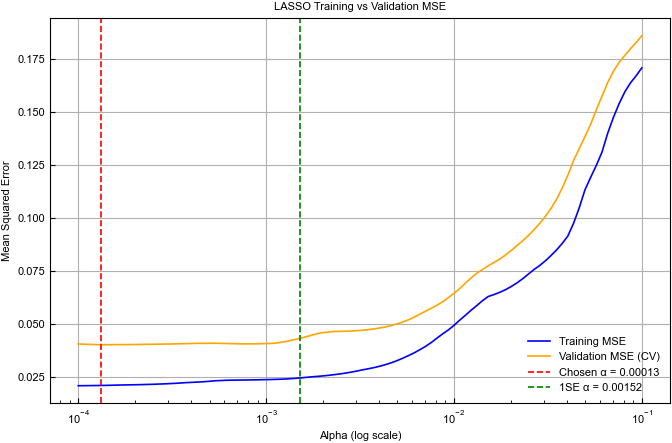

alpha = 0.00013
1SE α = 0.00152


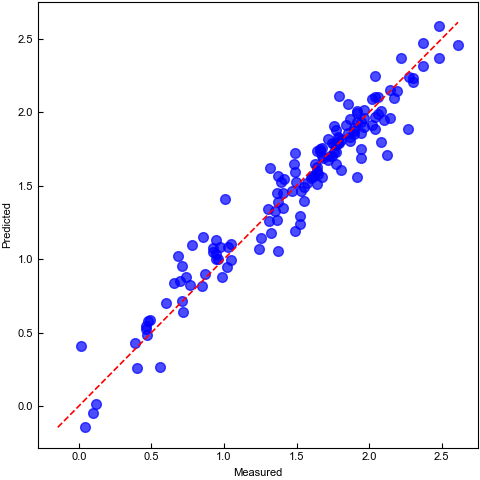

R^2: 0.934
MAE: 0.11
RMSE: 0.145
Intercept: 1.503572
x1                   0.030442
x2                   0.078296
x4                  -0.211863
x5                   0.728983
x6                  -0.059088
x7                   0.251393
x8                  -0.750983
x9                  -0.127215
x11                  0.074650
x12                 -0.619079
x13                 -0.169067
x14                 -0.553236
x15                 -0.586077
x17                 -0.223810
x19                 -0.267649
x20                  0.463893
x21                  0.578984
x22                 -0.262493
x23                  0.699874
x24                  0.012835
x25                  0.300531
x26                  0.080234
x27                 -0.148312
x28                  0.189628
x29                 -0.290564
x30                 -0.663271
x24subx11_squared    0.624282
dtype: float64
['x1', 'x2', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x11', 'x12', 'x13', 'x14', 'x15', 'x17', 'x19', 'x20', 'x21', 'x22', 'x2

In [11]:
X_scaled = scaler.fit_transform(X)  # exchange X with x_base for base feature modeling
n_bins = 5
y_binned = pd.qcut(
    y, q=n_bins, labels=False
)  # We group samples into bins to use a stratified k-fold split
alphas_list = np.logspace(-4, -1, 100)
# cv_method = RepeatedKFold(n_splits=5, n_repeats=4, random_state=42)
cv_method = RepeatedStratifiedKFold(n_splits=n_bins, n_repeats=4, random_state=42)
# av_mdl = LassoCV(cv=cv_method.split(X_scaled, y), alphas=alphas_list, random_state=42, max_iter=100000, n_jobs=-1).fit(X_scaled, y)              # for kfold
av_mdl = LassoCV(
    cv=cv_method.split(X_scaled, y_binned),
    alphas=alphas_list,
    random_state=42,
    max_iter=100000,
    n_jobs=-1,
).fit(
    X_scaled, y
)  
# for stratified kfold
# cv = RepeatedKFold(n_splits=4, n_repeats=2, random_state=42)        # option to determine the cv. If used, use cv=cv in LassoCV
# av_mdl = LassoCV(cv=4, random_state=42, max_iter=100000).fit(X_scaled, y)      # to compare it to a non nested CV model
y_predicted = av_mdl.predict(X_scaled)

# Plot a validation curve for the alpha grid
# Extract alphas and validation (CV) MSE
alphas_cv = av_mdl.alphas_
val_mse = np.mean(av_mdl.mse_path_, axis=1)
# --- Compute training MSE for each alpha ---
train_mse = []
for a in alphas_cv:
    lasso_cv = Lasso(alpha=a, max_iter=100000)
    lasso_cv.fit(X_scaled, y)
    y_pred = lasso_cv.predict(X_scaled)
    mse = mean_squared_error(y, y_pred)
    train_mse.append(mse)

# --------Calculate the 1-SE alpha------------------#
std_mse = np.std(av_mdl.mse_path_, axis=1)
# n_splits = cv_method.get_n_splits(X_scaled, y)
n_splits = cv_method.get_n_splits(X_scaled, y_binned)  # for stratified kfold
se_mse = std_mse / np.sqrt(n_splits)  # standard error for each alpha

idx_min = np.argmin(val_mse)
mse_min = val_mse[idx_min]
se_min = se_mse[idx_min]

threshold = mse_min + se_min
idx_1se = np.where(val_mse <= threshold)[0][0]
alpha_1se = av_mdl.alphas_[idx_1se]

# --- Plot both ---
plt.figure(figsize=(8, 5))
plt.semilogx(alphas_cv, train_mse, label="Training MSE", color="blue")
plt.semilogx(alphas_cv, val_mse, label="Validation MSE (CV)", color="orange")
plt.axvline(
    av_mdl.alpha_, color="red", linestyle="--", label=f"Chosen α = {av_mdl.alpha_:.5f}"
)
# plt.axvline(0.003, color='green', linestyle='--', label=f'Trial α = {0.003:.5f}')
plt.axvline(alpha_1se, color="green", linestyle="--", label=f"1SE α = {alpha_1se:.5f}")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean Squared Error")
plt.title("LASSO Training vs Validation MSE")
plt.legend()
plt.grid(True)
plt.show()

print("alpha =", np.round(av_mdl.alpha_, 5))
print(f"1SE α = {alpha_1se:.5f}")

plt.figure(figsize=(5, 5))
plt.scatter(y, y_predicted, alpha=0.7, label="Train", color="blue")
plt.xlabel("Measured")
plt.ylabel("Predicted")
min_val, max_val = min(y.min(), y_predicted.min()), max(y.max(), y_predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.tight_layout()
plt.show()

print("R^2:", np.round(r2_score(y, y_predicted), 3))
print("MAE:", np.round(mean_absolute_error(y_predicted, y), 3))
print("RMSE:", np.round(mean_squared_error(y_predicted, y) ** 0.5, 3))
print(f"Intercept: {av_mdl.intercept_:.6f}")

all_params = pd.Series(av_mdl.coef_, index=feature_names)[
    av_mdl.coef_ != 0
]  # Exchange feature_names with base_feature_names for base feature modeling
print(all_params)
all_params_list = all_params.index.to_list()
print(all_params_list)
sum_coef = np.sum(abs(av_mdl.coef_))
coef_threshold = 0.015 * sum_coef
main_model_terms = pd.Series(av_mdl.coef_, index=feature_names)[
    abs(av_mdl.coef_) > coef_threshold
]  # Exchange feature_names with base_feature_names for base feature modeling
print(main_model_terms)
main_params = main_model_terms.index.to_list()
print(main_params)
main_model_feature_df = feature_df[[id_col] + main_params]


### Y-Randomization Test

In [ ]:
# ---- Y-randomization test for the full LassoCV workflow ----
# Run this directly after the full LassoCV cell above.
# It repeats the same alpha-selection workflow with shuffled y values.
n_randomizations = 20
random_state = 42
rng = np.random.default_rng(random_state)

actual_yr_metrics = {
    "r2": r2_score(y, y_predicted),
    "mae": mean_absolute_error(y, y_predicted),
    "rmse": mean_squared_error(y, y_predicted) ** 0.5,
    "alpha": av_mdl.alpha_,
    "n_nonzero": int(np.sum(av_mdl.coef_ != 0)),
}


def _fit_y_randomized_lassocv(y_values):
    y_values_binned = pd.qcut(y_values, q=n_bins, labels=False)
    randomized_model = LassoCV(
        cv=cv_method.split(X_scaled, y_values_binned),
        alphas=alphas_list,
        random_state=random_state,
        max_iter=100000,
        n_jobs=-1,
    ).fit(X_scaled, y_values)
    y_values_predicted = randomized_model.predict(X_scaled)
    return {
        "r2": r2_score(y_values, y_values_predicted),
        "mae": mean_absolute_error(y_values, y_values_predicted),
        "rmse": mean_squared_error(y_values, y_values_predicted) ** 0.5,
        "alpha": randomized_model.alpha_,
        "n_nonzero": int(np.sum(randomized_model.coef_ != 0)),
        "y_random": y_values,
        "y_predicted": y_values_predicted,
    }


yr_results = []
for i in range(n_randomizations):
    y_random = rng.permutation(y)
    randomized_metrics = _fit_y_randomized_lassocv(y_random)
    randomized_metrics["iteration"] = i + 1
    yr_results.append(randomized_metrics)
    if (i + 1) % 20 == 0:
        print(f"Completed {i + 1}/{n_randomizations} randomizations")

yr_df = pd.DataFrame(yr_results)

yr_best_train_r2_idx = yr_df["r2"].idxmax()
yr_best_train_r2_model = yr_df.loc[yr_best_train_r2_idx]
yr_best_train_r2_iteration = int(yr_best_train_r2_model["iteration"])
yr_best_train_r2_y_random = yr_best_train_r2_model["y_random"]
yr_best_train_r2_pred = yr_best_train_r2_model["y_predicted"]

r2_p_value = (np.sum(yr_df["r2"] >= actual_yr_metrics["r2"]) + 1) / (
    n_randomizations + 1
)
mae_p_value = (np.sum(yr_df["mae"] <= actual_yr_metrics["mae"]) + 1) / (
    n_randomizations + 1
)
rmse_p_value = (np.sum(yr_df["rmse"] <= actual_yr_metrics["rmse"]) + 1) / (
    n_randomizations + 1
)

yr_summary_df = pd.DataFrame(
    {
        "metric": ["R2", "MAE", "RMSE", "alpha", "nonzero coefficients"],
        "actual_full_set": [
            actual_yr_metrics["r2"],
            actual_yr_metrics["mae"],
            actual_yr_metrics["rmse"],
            actual_yr_metrics["alpha"],
            actual_yr_metrics["n_nonzero"],
        ],
        "randomized_mean": [
            yr_df["r2"].mean(),
            yr_df["mae"].mean(),
            yr_df["rmse"].mean(),
            yr_df["alpha"].mean(),
            yr_df["n_nonzero"].mean(),
        ],
        "randomized_std": [
            yr_df["r2"].std(),
            yr_df["mae"].std(),
            yr_df["rmse"].std(),
            yr_df["alpha"].std(),
            yr_df["n_nonzero"].std(),
        ],
        "p_value": [r2_p_value, mae_p_value, rmse_p_value, np.nan, np.nan],
    }
)

display(yr_summary_df)

plt.figure(figsize=(5, 4))
plt.hist(yr_df["r2"], bins=20, alpha=0.75, color="lightgray", edgecolor="black")
plt.axvline(
    actual_yr_metrics["r2"],
    color="red",
    linestyle="--",
    label=f"Actual full-set R2 = {actual_yr_metrics['r2']:.3f}",
)
plt.xlabel("Full-set R2 after y-randomization")
plt.ylabel("Count")
plt.title(f"Y-randomization test (n = {n_randomizations})")
plt.legend()
plt.tight_layout()
plt.show()

yr_best_train_r2_stats_text = (
    f"R2 = {yr_best_train_r2_model['r2']:.3f}\n"
    f"MAE = {yr_best_train_r2_model['mae']:.3f}\n"
    f"alpha = {yr_best_train_r2_model['alpha']:.5f}\n"
    f"nonzero = {int(yr_best_train_r2_model['n_nonzero'])}"
)

lims = [
    min(yr_best_train_r2_y_random.min() - 0.5, yr_best_train_r2_pred.min() - 0.5),
    max(yr_best_train_r2_y_random.max() + 0.5, yr_best_train_r2_pred.max() + 0.5),
]

plt.figure(figsize=(3.3, 2.8))
plt.scatter(
    yr_best_train_r2_y_random,
    yr_best_train_r2_pred,
    color="#B8860B",
    alpha=0.65,
    s=30,
)
plt.plot(lims, lims, "k--", linewidth=1, alpha=0.3)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel(r"$\Delta\Delta G^{\ddagger}$ randomized training target (kcal/mol)")
plt.ylabel(r"$\Delta\Delta G^{\ddagger}$ predicted (kcal/mol)")
plt.title(f"Best training-R2 y-randomized model #{yr_best_train_r2_iteration}")
plt.text(
    0.03,
    0.97,
    yr_best_train_r2_stats_text,
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=8,
    bbox=dict(
        boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.75
    ),
)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

yr_best_train_r2_parity_png = os.path.join(
    output_folder, "lasso_y_randomized_best_training_r2.png"
)
yr_best_train_r2_parity_pdf = os.path.splitext(yr_best_train_r2_parity_png)[0] + ".pdf"
plt.savefig(yr_best_train_r2_parity_png, dpi=300, bbox_inches="tight")
plt.savefig(yr_best_train_r2_parity_pdf, bbox_inches="tight")
print(
    f"Best training-R2 y-randomized model: iteration {yr_best_train_r2_iteration}, R2 = {yr_best_train_r2_model['r2']:.3f}, RMSE = {yr_best_train_r2_model['rmse']:.3f}"
)
print(f"Saved best training-R2 y-randomized parity plot: {yr_best_train_r2_parity_png}")
print(
    f"Saved best training-R2 y-randomized parity plot PDF: {yr_best_train_r2_parity_pdf}"
)

plt.show()


## Refit the model on the whole dataset with a specified alpha

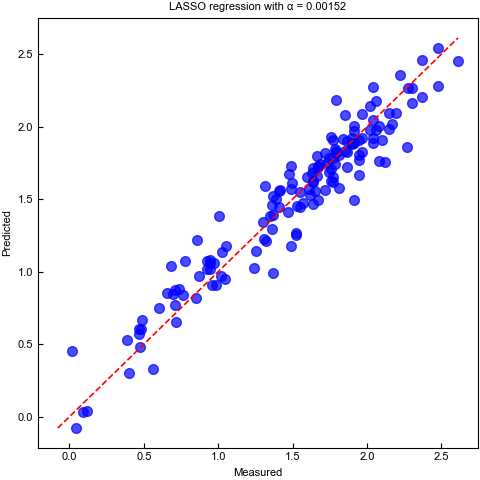

R^2: 0.923
MAE: 0.124
RMSE: 0.157
Intercept: 1.503572
x6                  -0.041738
x7                   0.044298
x8                  -0.154547
x9                  -0.038531
x11                 -0.024819
x12                 -0.273785
x13                  0.003064
x15                 -0.405329
x17                 -0.074095
x18                 -0.461572
x19                 -0.196821
x20                  0.395044
x21                  0.547201
x23                  0.238258
x24                  0.100168
x25                  0.021268
x26                  0.076597
x27                 -0.213990
x28                  0.137635
x29                 -0.196938
x30                 -0.421516
x24subx11_squared    0.540836
dtype: float64
22
x12                 -0.273785
x15                 -0.405329
x18                 -0.461572
x20                  0.395044
x21                  0.547201
x23                  0.238258
x30                 -0.421516
x24subx11_squared    0.540836
dtype: float64
['x12', 'x15'

,cat_substrate,x12,x15,x18,x20,x21,x23,x30,x24subx11_squared
0,KA2_A1,49.889827,85.779313,57.3710,-172.9063,-0.371293,65.001117,75.879021,326.463617
1,KA2_A2,49.889827,85.811665,57.5516,-172.4812,-0.371064,64.979701,75.971806,325.219781
2,KA2_A3,49.889827,86.184040,59.9950,-171.9441,-0.370103,65.159416,77.051048,328.519448
3,KA2_A4,49.889827,85.713948,55.5578,-171.9401,-0.369797,64.961077,76.032035,322.571971
4,KA2_A5,49.889827,86.567203,61.8149,-164.8952,-0.372869,68.952063,77.845423,25.498900
...,...,...,...,...,...,...,...,...,...
141,KA19_A11,74.521678,85.866782,59.5070,-183.3846,-0.363426,65.117513,76.126449,989.564421
142,KA19_A13,74.521678,86.032423,58.4561,-177.0278,-0.367723,64.802779,76.417828,991.440002
143,KA19_A14,74.521678,86.299589,62.9273,-178.9074,-0.365472,65.493705,76.473174,983.072264
144,KA19_A19,74.521678,88.578454,55.3841,-161.0883,-0.355071,71.584476,80.156921,667.348426


In [12]:
X_scaled = scaler.fit_transform(X)  # exchange X with x_base for base feature modeling
alpha = 0.00152
av_mdl = Lasso(alpha=alpha, max_iter=100000).fit(
    X_scaled, y
) 
y_predicted = av_mdl.predict(X_scaled)

plt.figure(figsize=(5, 5))
plt.scatter(y, y_predicted, alpha=0.7, label="Train", color="blue")
plt.xlabel("Measured")
plt.ylabel("Predicted")
plt.title(f"LASSO regression with α = {alpha:.5f}")
min_val, max_val = min(y.min(), y_predicted.min()), max(y.max(), y_predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.tight_layout()
plt.show()

print("R^2:", np.round(r2_score(y, y_predicted), 3))
print("MAE:", np.round(mean_absolute_error(y, y_predicted), 3))
print("RMSE:", np.round(mean_squared_error(y, y_predicted) ** 0.5, 3))
print(f"Intercept: {av_mdl.intercept_:.6f}")

all_params = pd.Series(av_mdl.coef_, index=feature_names)[
    av_mdl.coef_ != 0
]  # Exchange feature_names with base_feature_names for base feature modeling
print(all_params)
all_params_list = all_params.index.to_list()
print(len(all_params_list))

sum_coef = np.sum(abs(av_mdl.coef_))
coef_threshold = 0.05 * sum_coef
main_model_terms = pd.Series(av_mdl.coef_, index=feature_names)[
    abs(av_mdl.coef_) > coef_threshold
]  # Exchange feature_names with base_feature_names for base feature modeling
print(main_model_terms)
main_params = main_model_terms.index.to_list()
print(main_params)
main_model_feature_df = feature_df[[id_col] + main_params]
print(all_params_list)
display(main_model_feature_df)

# Build the feature df with scaled features for the realtive performance analysis later
scaled_feature_df = pd.DataFrame(
    X_scaled, columns=feature_names
)  # Exchange feature_names with base_df.columns
scaled_feature_df.insert(0, id_col, feature_df[id_col].values)
scaled_main_feature_df = scaled_feature_df[[id_col] + main_params]


## Relative Catalyst Ranking: Color Coding

In [ ]:
# Catalysts to highlight
highlight_catalysts = ["KA2", "KA8"]
highlight_substrates = ["A2", "A6"]

# Combine train and validation set into 1 DataFrame
color_df = pd.DataFrame(
    {
        "cat_substrate": df["cat_substrate"],
        "measured_ddG": y,
        "predicted_ddG": y_predicted,
    }
)

# Split into catalyst and substrate
color_df[["catalyst", "substrate"]] = color_df["cat_substrate"].str.split(
    "_", expand=True
)

# Filter the highlighted points
highlight_df = color_df[
    (color_df["catalyst"].isin(highlight_catalysts))
    & (color_df["substrate"].isin(highlight_substrates))
].copy()

if highlight_df.empty:
    raise ValueError(
        "No highlighted points found for the selected catalysts/substrates."
    )

# Assign muted colors only for the highlighted catalysts
unique_catalysts = highlight_df["catalyst"].unique()
muted_palette = ["#5E7D6A", "#B8860B", "#1F4E5F", "#8B1A1A", "#6B6F7A"]
catalyst_colors = {
    c: muted_palette[i % len(muted_palette)] for i, c in enumerate(unique_catalysts)
}

# Highlighted-point statistics
y_true_sub = highlight_df["measured_ddG"].values
y_pred_sub = highlight_df["predicted_ddG"].values
r2_ext_highlight = external_r2(y_true_sub, y_pred_sub, y)
r2_highlight = r2_score(y_true_sub, y_pred_sub)
r2 = r2_score(y, y_predicted)
mae_highlight = mean_absolute_error(y_true_sub, y_pred_sub)
mae = mean_absolute_error(y, y_predicted)

plt.figure(figsize=(3.1, 2.2))

# Plot all points as background
plt.scatter(
    color_df["measured_ddG"],
    color_df["predicted_ddG"],
    color="#7A7A7A",
    alpha=0.18,
    s=30,
)

# Highlight selected catalysts
for catalyst, group in highlight_df.groupby("catalyst"):
    color = catalyst_colors[catalyst]
    plt.scatter(
        group["measured_ddG"],
        group["predicted_ddG"],
        color=color,
        edgecolor="#5e5c5c00",
        linewidth=0.7,
        alpha=0.9,
        s=40,
        label=catalyst,
    )
    for _, row in group.iterrows():
        plt.text(
            row["measured_ddG"] + 0.04,
            row["predicted_ddG"] + 0.04,
            row["substrate"],
            fontsize=8,
            fontweight="semibold",
            color="#2F2F2F",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.7,
            ),
        )

lims = [
    min(color_df["measured_ddG"].min() - 0.5, color_df["predicted_ddG"].min() - 0.5),
    max(color_df["measured_ddG"].max() + 0.5, color_df["predicted_ddG"].max() + 0.5),
]
plt.plot(lims, lims, "k--", linewidth=1, alpha=0.3)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel(r"$\Delta\Delta G^{\ddagger}$ measured (kcal/mol)")
plt.ylabel(r"$\Delta\Delta G^{\ddagger}$ predicted (kcal/mol)")

stats_text = f"R$^2$ = {r2:.3f}\n" f"MAE = {mae:.3f}\n"
plt.text(
    0.03,
    0.97,
    stats_text,
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=8,
    bbox=dict(
        boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.75
    ),
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
highlight_handles_labels = [
    (h, l) for h, l in zip(handles, labels) if l in unique_catalysts
]
if highlight_handles_labels:
    highlight_handles_labels.sort(
        key=lambda x: int("".join(ch for ch in x[1] if ch.isdigit()) or 0)
    )
    sorted_handles, sorted_labels = zip(*highlight_handles_labels)
    ax.legend(
        sorted_handles, sorted_labels, title="Catalysts", loc="best", frameon=False
    )

plt.tight_layout()

highlight_cat_tag = "_".join(str(c) for c in highlight_catalysts)
highlight_sub_tag = "_".join(str(s) for s in highlight_substrates)
catalyst_ranking_png = os.path.join(
    output_folder,
    f"lasso_relative_catalyst_ranking_{highlight_cat_tag}_{highlight_sub_tag}_int.png",
)
catalyst_ranking_pdf = os.path.splitext(catalyst_ranking_png)[0] + ".pdf"
plt.savefig(catalyst_ranking_png, dpi=300, bbox_inches="tight")
plt.savefig(catalyst_ranking_pdf, bbox_inches="tight")
print(f"Saved parity plot: {catalyst_ranking_png}")
print(f"Saved parity plot PDF: {catalyst_ranking_pdf}")

plt.show()

print(highlight_df)
print("\n")


def show_parameters(df1, df2):
    matches = []
    for name in df2.iloc[:, 0]:
        matches_x = df1[df1.iloc[:, 0].str.fullmatch(name, case=False, na=False)]
        if not matches_x.empty:
            matches.append(matches_x)

    if matches:
        param_contr_df = pd.concat(matches, axis=0)
        display(param_contr_df)
    else:
        print("No matches found.")
        return None


print("Feature Contributions:")
show_parameters(main_model_feature_df, highlight_df)

print("Using scaled features:")
show_parameters(scaled_main_feature_df, highlight_df)

print("External R² for highlighted datapoints:", np.round(r2_ext_highlight, 3))
print("R² for highlighted datapoints:", np.round(r2_highlight, 3))
print("MAE for highlighted datapoints:", np.round(mae_highlight, 3))


## External Test Predictions

In [ ]:
# ----- External Tests ------

# Plot external-test target distribution in the same clean style as the other figures
plt.figure(figsize=(2, 2))
plt.hist(
    y_external,
    bins=8,
    alpha=0.85,
    label="External test set",
    color="#55A14E",
    edgecolor="white",
    linewidth=0.8,
)
plt.xlabel(r"$\Delta\Delta G^{\ddagger}$ (kcal/mol)")
plt.ylabel("Count")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("External Test Set Size:", len(y_external))
print("Test/Train Ratio:", np.round(len(y_external) / len(y), 2))
print("\n")

x_external_scaled = scaler.transform(
    x_external
)  # Exchange x_external with x_base_external for base feature modeling
external_metrics = external_test_metrics(av_mdl, x_external_scaled, y_external)
abs_deviations = np.abs(df_ext["ddG"] - external_metrics["y_external_pred"])

ext_results_df = pd.DataFrame(
    {
        ext_id_col: df_ext[ext_id_col],
        "ddG_measured": df_ext["ddG"],
        "ddG_predicted": external_metrics["y_external_pred"],
        "abs_deviation": abs_deviations,
    }
)

print("Results external test\n")
print("R^2:", np.round(external_metrics["External R2"], 3))
print(
    "External R^2:",
    np.round(external_r2(y_external, external_metrics["y_external_pred"], y), 3),
)
print("MAE:", np.round(external_metrics["External MAE"], 3))

plt.figure(figsize=(4, 4))
plt.scatter(y, y_predicted, alpha=0.7, label="Train", color="blue")
plt.scatter(
    y_external,
    external_metrics["y_external_pred"],
    alpha=0.7,
    label="Ext. Test",
    color="green",
)
min_val, max_val = min(y.min(), y_predicted.min()), max(y.max(), y_predicted.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
plt.xlabel(r"$\Delta\Delta G$ Measured", fontsize=16)
plt.ylabel(r"$\Delta\Delta G$ Predicted", fontsize=16)
plt.title("LASSO Model", fontsize=16)
plt.legend(fontsize=14)
plt.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

display(ext_results_df.round(3))


In [ ]:
# Plot train + external-test parity plot in the same layout as the final LOGO result
# Set to [] for no highlighted external-test substrates
# external_highlight_substrates = ['A8', 'A7', 'vsa1']
external_highlight_substrates = ["A8", "A7"]

train_parity_df = pd.DataFrame(
    {
        "measured_ddG": y,
        "predicted_ddG": y_predicted,
    }
)

external_parity_df = ext_results_df.rename(
    columns={"ddG_measured": "measured_ddG", "ddG_predicted": "predicted_ddG"}
).copy()
external_parity_df[ext_id_col] = external_parity_df[ext_id_col].astype(str)
external_parity_df["highlight_group"] = (
    external_parity_df[ext_id_col].str.split("_").str[-1]
)

train_final_r2 = r2_score(
    train_parity_df["measured_ddG"], train_parity_df["predicted_ddG"]
)
train_final_mae = mean_absolute_error(
    train_parity_df["measured_ddG"], train_parity_df["predicted_ddG"]
)
external_final_r2 = r2_score(
    external_parity_df["measured_ddG"], external_parity_df["predicted_ddG"]
)
external_final_ext_r2 = external_r2(y_external, external_metrics["y_external_pred"], y)
external_final_mae = mean_absolute_error(
    external_parity_df["measured_ddG"], external_parity_df["predicted_ddG"]
)

print("Train stats:")
print(f"R^2  = {train_final_r2:.3f}")
print(f"MAE  = {train_final_mae:.3f}")
print("\nFinal external-test stats:")
print(f"R^2  = {external_final_r2:.3f}")
print(f"External R^2  = {external_final_ext_r2:.3f}")
print(f"MAE  = {external_final_mae:.3f}")

highlight_cmap = plt.get_cmap("Greens")
green_shades = np.linspace(0.55, 0.85, max(len(external_highlight_substrates), 1))
external_highlight_palette = {
    str(substrate): highlight_cmap(green_shades[i])
    for i, substrate in enumerate(external_highlight_substrates)
}

# plt.figure(figsize=(3.3, 2.4))
plt.figure(figsize=(2, 2))

plt.scatter(
    train_parity_df["measured_ddG"],
    train_parity_df["predicted_ddG"],
    color="grey",
    alpha=0.4,
    s=30,
    label="Train",
)

plt.scatter(
    external_parity_df["measured_ddG"],
    external_parity_df["predicted_ddG"],
    # color="darkred",
    color="#2A5160",
    alpha=0.6,
    s=30,
    label="Test",
)
"""
for substrate in external_highlight_substrates:
    point_df = external_parity_df[external_parity_df['highlight_group'] == str(substrate)]
    if point_df.empty:
        continue
    point_color = external_highlight_palette.get(str(substrate), '#7d5555')
    plt.scatter(
        point_df['measured_ddG'],
        point_df['predicted_ddG'],
        #color="darkred",
        color="#2A5160",
        #edgecolor='#5e5c5c00',
        linewidth=0.8,
        alpha=1.0,
        s=40,
    )
"""
all_measured = pd.concat(
    [train_parity_df["measured_ddG"], external_parity_df["measured_ddG"]],
    ignore_index=True,
)
all_predicted = pd.concat(
    [train_parity_df["predicted_ddG"], external_parity_df["predicted_ddG"]],
    ignore_index=True,
)
lims = [
    min(all_measured.min() - 0.5, all_predicted.min() - 0.5),
    max(all_measured.max() + 0.5, all_predicted.max() + 0.5),
]
plt.plot(lims, lims, "k--", linewidth=1, alpha=0.3)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel(r"$\Delta\Delta G^{\ddagger}$ measured (kcal/mol)")
plt.ylabel(r"$\Delta\Delta G^{\ddagger}$ predicted (kcal/mol)")

stats_text = (
    f"Train R$^2$ = {train_final_r2:.3f}\n"
    f"Train MAE = {train_final_mae:.3f}\n"
    f"Test R$^2$ = {external_final_r2:.3f}\n"
    f"Test MAE = {external_final_mae:.3f}\n"
)
"""
plt.text(
    0.03, 0.97, stats_text,
    transform=plt.gca().transAxes,
    ha='left', va='top',
    fontsize=8,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.75),
)
"""
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.legend(loc='best', frameon=True)

plt.tight_layout()

external_parity_png = os.path.join(output_folder, "lasso_external_test.png")
external_parity_pdf = os.path.splitext(external_parity_png)[0] + ".pdf"
plt.savefig(external_parity_png, dpi=300, bbox_inches="tight")
plt.savefig(external_parity_pdf, bbox_inches="tight")
print(f"Saved parity plot: {external_parity_png}")
print(f"Saved parity plot PDF: {external_parity_pdf}")

plt.show()


## Virtual Screening

### Retrain the model on the whole dataset

In [ ]:
# ------------------------------ Combine train and test set --------------------------------
X_full = np.vstack([X, x_external])
y_full = np.concatenate([y, y_external])

# ------------------------------ LASSO CV on whole set -------------------------------------
cv_method = RepeatedKFold(n_splits=5, n_repeats=4, random_state=42)
alphas_list = np.logspace(-4, -1, 100)

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "lasso",
            LassoCV(
                alphas=alphas_list,
                cv=cv_method.split(X_full, y_full),
                max_iter=100000,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

pipe.fit(X_full, y_full)

alpha_min = pipe.named_steps["lasso"].alpha_
print("alpha_min =", np.round(alpha_min, 5))

y_predicted = pipe.predict(X_full)

# ---------------------------------- 1-SE alpha ------------------------------------------
lasso = pipe.named_steps["lasso"]

alphas_cv = lasso.alphas_
val_mse = np.mean(lasso.mse_path_, axis=1)
std_mse = np.std(lasso.mse_path_, axis=1)

n_splits = cv_method.get_n_splits(X_full, y_full)
se_mse = std_mse / np.sqrt(n_splits)

idx_min = np.argmin(val_mse)
threshold = val_mse[idx_min] + se_mse[idx_min]
idx_1se = np.where(val_mse <= threshold)[0][0]
alpha_1se = alphas_cv[idx_1se]

print(f"1SE alpha = {alpha_1se:.5f}")

# ------------------------ Get the alpha vs MSE curve ------------------------------------
train_mse = []

for a in alphas_cv:
    mdl = Pipeline(
        [("scaler", StandardScaler()), ("lasso", Lasso(alpha=a, max_iter=100000))]
    )
    mdl.fit(X_full, y_full)
    y_hat = mdl.predict(X_full)
    train_mse.append(mean_squared_error(y_full, y_hat))

coef = pipe.named_steps["lasso"].coef_
all_params = pd.Series(coef, index=feature_names)[coef != 0]

# ------------------------- Plot alpha MSE curve ------------------------------------------
plt.figure(figsize=(8, 5))
plt.semilogx(alphas_cv, train_mse, label="Training MSE", color="blue")
plt.semilogx(alphas_cv, val_mse, label="Validation MSE (CV)", color="orange")
plt.axvline(alpha_min, color="red", linestyle="--", label=f"Min α = {alpha_min:.5f}")
# plt.axvline(0.003, color='green', linestyle='--', label=f'Trial α = {0.003:.5f}')
plt.axvline(alpha_1se, color="green", linestyle="--", label=f"1SE α = {alpha_1se:.5f}")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean Squared Error")
plt.title("LASSO Training vs Validation MSE")
plt.legend()
plt.grid(True)
plt.show()

# --------------------- Plot min alpha Model -----------------------------------------------
plt.figure(figsize=(5, 5))
plt.title(f"alpha = {alpha_min:.5f}")
plt.scatter(y_full, y_predicted, alpha=0.7, label="Train", color="blue")
plt.xlabel("Measured")
plt.ylabel("Predicted")
min_val, max_val = min(y.min(), y_predicted.min()), max(y.max(), y_predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.tight_layout()
plt.show()

print("R^2:", np.round(r2_score(y_predicted, y_full), 3))
print("MAE:", np.round(mean_absolute_error(y_predicted, y_full), 3))
print("RMSE:", np.round(mean_squared_error(y_predicted, y_full) ** 0.5, 3))
print(f"Intercept: {pipe.named_steps['lasso'].intercept_:.6f}")

all_params_list = all_params.index.to_list()
print(all_params_list)
print(len(all_params_list))
sum_coef = np.sum(abs(coef))
coef_threshold = 0.015 * sum_coef
main_model_terms = pd.Series(coef, index=feature_names)[
    abs(coef) > coef_threshold
]  # Exchange feature_names with base_feature_names for base feature modeling
print(main_model_terms)
main_params_lasso = main_model_terms.index.to_list()
print(main_params_lasso)
print(len(main_params_lasso))
main_model_feature_df_lasso = feature_df[[id_col] + main_params_lasso]

# -------------------------------- Plot 1SE Alpha Model ------------------------------------------
X_scaled = scaler.fit_transform(X_full)
model_1se = Lasso(alpha=alpha_1se, max_iter=100000).fit(X_scaled, y_full)
y_predicted_1se = model_1se.predict(X_scaled)
coef = model_1se.coef_
all_params = pd.Series(coef, index=feature_names)[coef != 0]

plt.figure(figsize=(5, 5))
plt.title(f"alpha = {alpha_1se:.5f}")
plt.scatter(y_full, y_predicted_1se, alpha=0.7, label="Train", color="blue")
plt.xlabel("Measured")
plt.ylabel("Predicted")
min_val, max_val = min(y.min(), y_predicted_1se.min()), max(
    y.max(), y_predicted_1se.max()
)
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.tight_layout()
plt.show()

print("R^2:", np.round(r2_score(y_predicted_1se, y_full), 3))
print("MAE:", np.round(mean_absolute_error(y_predicted_1se, y_full), 3))
print("RMSE:", np.round(mean_squared_error(y_predicted_1se, y_full) ** 0.5, 3))
print(f"Intercept: {model_1se.intercept_:.6f}")

all_params_list = all_params.index.to_list()
print(all_params_list)
print(len(all_params_list))
sum_coef = np.sum(abs(coef))
coef_threshold = 0.015 * sum_coef
main_model_terms = pd.Series(coef, index=feature_names)[
    abs(coef) > coef_threshold
]  # Exchange feature_names with base_feature_names for base feature modeling
print(main_model_terms)
main_params_1se = main_model_terms.index.to_list()
print(main_params_1se)
print(len(main_params_1se))
main_model_feature_df_1se = feature_df[[id_col] + main_params_1se]
display(main_model_feature_df_1se)

# ------------------------------ Model with previously found alpha -------------------------------
alpha = 0.00152
X_scaled = scaler.fit_transform(X_full)
model_custom = Lasso(alpha=alpha, max_iter=100000).fit(X_scaled, y_full)
y_predicted_custom = model_custom.predict(X_scaled)
coef = model_custom.coef_
all_params = pd.Series(coef, index=feature_names)[coef != 0]

plt.figure(figsize=(5, 5))
plt.title(f"alpha = {alpha:.5f}")
plt.scatter(y_full, y_predicted_custom, alpha=0.7, label="Train", color="blue")
plt.xlabel("Measured")
plt.ylabel("Predicted")
min_val, max_val = min(y.min(), y_predicted_custom.min()), max(
    y.max(), y_predicted_custom.max()
)
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.tight_layout()
plt.show()

print("R^2:", np.round(r2_score(y_predicted_custom, y_full), 3))
print("MAE:", np.round(mean_absolute_error(y_predicted_custom, y_full), 3))
print("RMSE:", np.round(mean_squared_error(y_predicted_custom, y_full) ** 0.5, 3))
print(f"Intercept: {model_custom.intercept_:.6f}")

all_params_list = all_params.index.to_list()
print(all_params_list)
print(len(all_params_list))
sum_coef = np.sum(abs(coef))
coef_threshold = 0.015 * sum_coef
main_model_terms = pd.Series(coef, index=feature_names)[
    abs(coef) > coef_threshold
]  # Exchange feature_names with base_feature_names for base feature modeling
print(main_model_terms)
main_params_custom = main_model_terms.index.to_list()
print(main_params_custom)
print(len(main_params_custom))
main_model_feature_df_custom = feature_df[[id_col] + main_params_custom]


### Predictions

Only usable when training on the virtual-screening or out-of-sample-catalysts datasets

In [ ]:
# Read in virtual screen data
vs_file = "virtual_screen_set.csv"
# vsa1 = N-Me isatine, vsa2 = N-H isatine
df_vs = pd.read_csv(input_folder + vs_file)
print("Virtual Screen df:")
display(df_vs)
print("\n")
vs_id_col = id_col if id_col in df_vs.columns else df_vs.columns[0]
df_vs_params = df_vs.drop(columns=[vs_id_col])
df_vs_base = df_vs.filter(regex=r"^x\d+$")
### To add a specific interaction term
# df_vs_base = pd.concat([df_vs_base, df_vs_params[["x24subx11_squared"]]], axis=1)
# df_vs_base = df_vs_base.drop(columns='x12')
# df_vs_base = df_vs_base.drop(columns='x4')
# df_vs_base = df_vs_base.drop(columns='x8')
###
x_base_vs = df_vs_base.values

# Check that all parameters from the original dataset are present and put them in the same order (this is necessary especially for SISSO to remove too big cols again)
try:
    df_vs_params = df_vs_params[feature_names]
except KeyError:
    print(
        "There are features in the main dataset that are not present in this parameter file."
    )
    print(
        "If your model was built with scaled features, this will cause an error downstream."
    )

    # Remove all columns that are not in the original dataset
    columns_to_keep = [col for col in df_vs_params.columns if col in feature_names]
    df_vs_params = df_vs_params[columns_to_keep]

x_vs = df_vs_params.values
x_vs_scaled = scaler.transform(x_vs)


In [ ]:
# Choose which model to use for virtual screening
# "lasso" for the min alpha model
# "model_1se" for the 1se alpha model
# "model_custom" for the model with specified alpha
model = model_custom

x_vs_scaled = scaler.transform(x_vs)
y_predicted = model.predict(X_scaled)
y_vs_predicted = model.predict(x_vs_scaled)
vs_results_df = pd.DataFrame({vs_id_col: df_vs[vs_id_col], "y_vs": y_vs_predicted})
print("Virtual Screen Results:")
display(vs_results_df)
print("\n")

if model != lasso:
    vs_results_file = f"virtual_screen_predictions_alpha_{model.alpha:.4f}.xlsx"
else:
    vs_results_file = f"virtual_screen_predictions_alpha_{alpha_min:.4f}.xlsx"
vs_results_df.to_excel(output_folder + vs_results_file, index=False)
print(f"Saved virtual screening predictions to: {output_folder + vs_results_file}")

plt.figure(figsize=(5, 5))
plt.scatter(y_full, y_predicted, alpha=0.7, label="Train", color="blue")
plt.scatter(
    y_vs_predicted, y_vs_predicted, alpha=0.7, label="Virtual Screening", color="red"
)
plt.xlabel("Measured")
plt.ylabel("Predicted")
if model != lasso:
    plt.title(f"Virtual Screening Predictions (α = {model.alpha:.4f})")
else:
    plt.title(f"Virtual Screening Predictions (α = {alpha_min:.4f})")
plt.legend()

plt.tight_layout()
plt.show()

# model_feature_df = feature_df[["cat_substrate"] + all_params_list]
if model == model_1se:
    vs_main_feature_df = df_vs[[vs_id_col] + main_params_1se]
elif model == model_custom:
    vs_main_feature_df = df_vs[[vs_id_col] + main_params_custom]
else:
    vs_main_feature_df = df_vs[[vs_id_col] + main_params_lasso]

print("Feature Contributions:")
show_parameters(vs_main_feature_df, vs_results_df)

"""
# compare to catalyst from training set
compare_to = "KA2"
print("Compare to Training Set:")
if model == model_1se:
    df_1se = main_model_feature_df_1se[main_model_feature_df_1se[id_col] == compare_to]
    comparison_df = pd.concat([df_1se, vs_main_feature_df], ignore_index=True)
elif model == model_custom:
    df_custom = main_model_feature_df_custom[main_model_feature_df_custom[id_col] == compare_to]
    comparison_df = pd.concat([df_custom, vs_main_feature_df], ignore_index=True)
else:
    df_lasso = main_model_feature_df_lasso[main_model_feature_df_lasso[id_col] == compare_to]
    comparison_df = pd.concat([df_lasso, vs_main_feature_df], ignore_index=True)

display(comparison_df)
"""


### Plot the predictions

In [ ]:
from pathlib import Path
import re

alpha_prediction_entries = []
vs_prediction_files = sorted(
    Path(output_folder).glob("virtual_screen_predictions_alpha_*.xlsx")
)
if not vs_prediction_files:
    raise FileNotFoundError(
        f"No virtual screening prediction files found in {output_folder}."
    )

for prediction_file in vs_prediction_files:
    alpha_match = re.search(r"alpha_([0-9.]+)\.xlsx$", prediction_file.name)
    if alpha_match is None:
        raise ValueError(f"Could not parse alpha value from {prediction_file.name}")

    alpha_value = float(alpha_match.group(1))
    alpha_label = (
        f"alpha_{alpha_match.group(1)}" if alpha_match else prediction_file.stem
    )

    pred_df = pd.read_excel(prediction_file)
    required_cols = {vs_id_col, "y_vs"}
    if not required_cols.issubset(pred_df.columns):
        raise ValueError(
            f"Unexpected columns in {prediction_file.name}: {list(pred_df.columns)}"
        )

    alpha_prediction_entries.append(
        (
            alpha_value,
            alpha_label,
            pd.to_numeric(pred_df.set_index(vs_id_col)["y_vs"], errors="coerce"),
        )
    )

alpha_prediction_entries.sort(key=lambda item: item[0])
alpha_cols = [label for _, label, _ in alpha_prediction_entries]
vs_summary_df = pd.DataFrame(
    {label: series for _, label, series in alpha_prediction_entries}
)

ordered_ids = df_vs[vs_id_col].astype(str).tolist()
vs_summary_df.index = vs_summary_df.index.astype(str)
vs_summary_df = vs_summary_df.reindex(ordered_ids)

missing_prediction_rows = vs_summary_df[alpha_cols].isna().any(axis=1).sum()
if missing_prediction_rows:
    print(
        f"Warning: {missing_prediction_rows} candidates are missing at least one alpha prediction."
    )

vs_summary_df["mean_pred"] = vs_summary_df[alpha_cols].mean(axis=1, skipna=True)
vs_summary_df["min_pred"] = vs_summary_df[alpha_cols].min(axis=1, skipna=True)
vs_summary_df["max_pred"] = vs_summary_df[alpha_cols].max(axis=1, skipna=True)
vs_summary_df["range_pred"] = vs_summary_df["max_pred"] - vs_summary_df["min_pred"]
vs_summary_df = vs_summary_df.reset_index().rename(columns={"index": vs_id_col})
vs_summary_df = vs_summary_df.sort_values(
    ["mean_pred", "range_pred"], ascending=[False, True]
).reset_index(drop=True)

vs_summary_display_df = vs_summary_df[
    [vs_id_col, "mean_pred", "min_pred", "max_pred", "range_pred"]
].copy()
vs_summary_display_df["mean_plus_range"] = vs_summary_display_df.apply(
    lambda row: f"{row['mean_pred']:.3f} [{row['min_pred']:.3f}, {row['max_pred']:.3f}]",
    axis=1,
)

summary_file = (
    Path(output_folder) / "virtual_screen_predictions_mean_min_max_summary.csv"
)
plot_file = Path(output_folder) / "virtual_screen_predictions_mean_min_max_ranges.png"
plot_pdf_file = plot_file.with_suffix(".pdf")
vs_summary_df.to_csv(summary_file, index=False)

display(vs_summary_display_df[[vs_id_col, "mean_plus_range", "range_pred"]])

gas_constant_kcal_mol_K = 0.00198720425864083
temperature_K = 298.15
rt_kcal_mol = gas_constant_kcal_mol_K * temperature_K


def ddg_to_ee(ddg_values):
    ddg_values = np.asarray(ddg_values, dtype=float)
    er_values = np.exp(ddg_values / rt_kcal_mol)
    ee_values = 100.0 * (er_values - 1.0) / (er_values + 1.0)
    return np.clip(ee_values, -99.999, 99.999)


def ee_to_ddg(ee_values):
    ee_values = np.asarray(ee_values, dtype=float) / 100.0
    ee_values = np.clip(ee_values, -0.999999, 0.999999)
    er_values = (1.0 + ee_values) / (1.0 - ee_values)
    return rt_kcal_mol * np.log(er_values)


vs_plot_df = vs_summary_df.copy()
fig_width = max(4.8, 0.60 * len(vs_plot_df) + 1.2)
fig, ax_ddg = plt.subplots(figsize=(fig_width, 3.3))
x_pos = np.arange(len(vs_plot_df), dtype=float)

yerr = np.vstack(
    [
        vs_plot_df["mean_pred"] - vs_plot_df["min_pred"],
        vs_plot_df["max_pred"] - vs_plot_df["mean_pred"],
    ]
)

ax_ddg.errorbar(
    x_pos,
    vs_plot_df["mean_pred"],
    yerr=yerr,
    fmt="o",
    color="#1f4e79",
    ecolor="#88a8c8",
    elinewidth=1.15,
    capsize=2.8,
    markersize=4.8,
    zorder=3,
)

ax_ddg.set_xticks(x_pos)
ax_ddg.set_xticklabels(vs_plot_df[vs_id_col], rotation=45, ha="right")
ax_ddg.set_xlabel("Candidate")
ax_ddg.set_ylabel("Predicted ddG (kcal/mol)")
ax_ddg.spines["top"].set_visible(False)
ax_ddg.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.8)
ax_ddg.set_axisbelow(True)

if len(x_pos) == 1:
    ax_ddg.set_xlim(x_pos[0] - 0.45, x_pos[0] + 0.45)
else:
    ax_ddg.set_xlim(x_pos[0] - 0.40, x_pos[-1] + 0.40)

ddg_axis_min = min(0.0, float(vs_plot_df["min_pred"].min()) - 0.05)
ddg_axis_max = float(vs_plot_df["max_pred"].max()) + 0.08
ax_ddg.set_ylim(ddg_axis_min, ddg_axis_max)

ax_ee = ax_ddg.secondary_yaxis("right", functions=(ddg_to_ee, ee_to_ddg))
ax_ee.set_ylabel("ee (%)")
ee_tick_candidates = np.array([0, 20, 40, 60, 80, 90, 95, 98], dtype=float)
ee_axis_min = float(ddg_to_ee(ddg_axis_min))
ee_axis_max = float(ddg_to_ee(ddg_axis_max))
ee_ticks = ee_tick_candidates[
    (ee_tick_candidates >= ee_axis_min - 1e-9)
    & (ee_tick_candidates <= ee_axis_max + 1e-9)
]
if ee_ticks.size >= 2:
    ax_ee.set_yticks(ee_ticks)
ax_ee.spines["top"].set_visible(False)

fig.tight_layout()
fig.savefig(plot_file, dpi=300, bbox_inches="tight")
fig.savefig(plot_pdf_file, bbox_inches="tight")
plt.show()

print(f"Used alpha prediction files: {[path.name for path in vs_prediction_files]}")
print(f"Saved summary to: {summary_file}")
print(f"Saved plot to: {plot_file}")
print(f"Saved plot PDF to: {plot_pdf_file}")


# PCA 

In [ ]:
n_components = 2  # set your number of PCA components
model_features = True  # set true, if you only want to do the pca with features from the final regression model, set False for all features from the input csv
only_main_feat = True  # set true, if you only want to do the pca with the model features with the highest coefficients
base_features = True  # set true, if you want just PCA with the base features, set False for all SISSO features
substrate_features = (
    True  # set true to restrict PCA to substrate base features x14..x30 only
)
# -----------------------------------------------------


def is_substrate_base_feature(col_name):
    name = str(col_name)
    if not name.startswith("x"):
        return False
    if not name[1:].isdigit():
        return False
    idx = int(name[1:])
    return 14 <= idx <= 30


substrate_feature_cols = [c for c in df.columns if is_substrate_base_feature(c)]

# Build PCA feature matrix on the full dataset: train + external test
ext_pca_id_col = (
    ext_id_col
    if "ext_id_col" in globals()
    else (id_col if id_col in df_ext.columns else df_ext.columns[0])
)
train_ids = df[id_col].astype(str).values
ext_ids = df_ext[ext_pca_id_col].astype(str).values
all_ids = np.concatenate([train_ids, ext_ids])
all_ddg = np.concatenate([y, y_external])
all_dataset = np.array(["train"] * len(train_ids) + ["external_test"] * len(ext_ids))

if model_features:

    if only_main_feat:
        selected_features = list(main_params)
    else:
        selected_features = list(all_params.index.to_list())

    if base_features:
        selected_features = [c for c in selected_features if str(c).startswith("x")]

    if substrate_features:
        selected_features = [
            c for c in selected_features if c in substrate_feature_cols
        ]

    if len(selected_features) == 0:
        raise ValueError(
            "No PCA features left after applying filters (model_features/base_features/substrate_features)."
        )

    train_pca_features = df[selected_features].copy()
    ext_pca_features = df_ext[selected_features].copy()
    pca_features_df = pd.concat(
        [train_pca_features, ext_pca_features], axis=0, ignore_index=True
    )
    pca_features_scaled = scaler.fit_transform(pca_features_df)
    pca_feature_names = pca_features_df.columns

else:

    if base_features:
        selected_features = list(df.filter(regex=r"^x\d+$").columns)
    else:
        selected_features = list(feature_names)

    if substrate_features:
        selected_features = [
            c for c in selected_features if c in substrate_feature_cols
        ]

    if len(selected_features) == 0:
        raise ValueError(
            "No PCA features left after applying filters (base_features/substrate_features)."
        )

    train_pca_features = df[selected_features].copy()
    ext_pca_features = df_ext[selected_features].copy()
    pca_features_df = pd.concat(
        [train_pca_features, ext_pca_features], axis=0, ignore_index=True
    )
    pca_features_scaled = scaler.fit_transform(pca_features_df)
    pca_feature_names = pca_features_df.columns

print(f"PCA feature count: {len(pca_feature_names)}")
if substrate_features:
    print("Using substrate-only features (x14..x30).")

pca = PCA(n_components, random_state=42)
pca_results = pca.fit_transform(pca_features_scaled)
pca_score = pca.explained_variance_ratio_

print("Total variance explained:", round(np.sum(pca_score * 100), 1), "%\n")
print(pca_score)

pca_df = pd.DataFrame(pca_results, columns=[f"PC{i+1}" for i in range(n_components)])

plt.figure(figsize=(8, 6))
plt.scatter(
    pca_df["PC1"], pca_df["PC2"], alpha=0.7, color="royalblue", marker="o", s=50
)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.xticks([])
plt.yticks([])

plt.show()

pca_df["ddG"] = all_ddg
pca_df["dataset"] = all_dataset
pca_df.index = all_ids
display(pca_df)


In [ ]:
# ---------------- Interactive 2D PCA Plot ---------------------------

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    # color="mean_ddG",                # color scale based on mean ddG per substrate
    # hover_data=["mean_ddG"],         # show mean ddG when hovering
)

# Add cat_substrate index to hover info
pca_df_hover = pca_df.reset_index()  # ensure index is a column
fig = px.scatter(
    pca_df_hover,
    x="PC1",
    y="PC2",
    color="ddG",
    hover_data={pca_df_hover.columns[0]: True, "ddG": True},
)

fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color="DarkSlateGrey")))
fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    coloraxis_colorbar=dict(title="ddG"),
    width=600,
    height=600,
)

fig.show()

feature_contribs = pd.DataFrame(
    pca.components_.T,
    index=pca_feature_names,
    columns=[f"PC{i+1}" for i in range(n_components)],
)
# .T transposes the data so that instead of having th PCA component as (n_compenents, n_features; aka the features as columns and PCAs as rows), you have the opposite(features as the columns and PCs as the columns)
display(feature_contribs)
# option to save to excel file
feature_contribs.to_excel(output_folder + "PCA_contributions.xlsx")


In [ ]:
# Static PCA plot in the same layout as the saved parity plots
# Use a more contrastful, perceptually uniform palette for ddG
pca_ddg_cmap = plt.get_cmap("viridis")

pc1_var = pca_score[0] * 100
pc2_var = pca_score[1] * 100

plt.figure(figsize=(5, 4))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["ddG"],
    cmap=pca_ddg_cmap,
    s=55,
    alpha=0.9,
    edgecolor="#5e5c5c20",
    linewidth=0.4,
)

plt.xlabel(f"PC1 ({pc1_var:.1f}%)")
plt.ylabel(f"PC2 ({pc2_var:.1f}%)")

variance_text = f"PC1 = {pc1_var:.1f}%\n" f"PC2 = {pc2_var:.1f}%\n"
plt.text(
    0.03,
    0.97,
    variance_text,
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.75
    ),
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cbar = plt.colorbar(scatter)
cbar.set_label(r"$\Delta\Delta G^{\ddagger}$ (kcal/mol)")
cbar.outline.set_visible(False)

plt.tight_layout()

pca_static_png = os.path.join(output_folder, "pca_ddg_static.png")
pca_static_pdf = os.path.splitext(pca_static_png)[0] + ".pdf"
plt.savefig(pca_static_png, dpi=300, bbox_inches="tight")
plt.savefig(pca_static_pdf, bbox_inches="tight")
print(f"Saved PCA plot: {pca_static_png}")
print(f"Saved PCA plot PDF: {pca_static_pdf}")

plt.show()


In [ ]:
# Make sure your df has columns: PC1, PC2, PC3, ddG
d3_df = pca_df.reset_index()  # keep index as a column for hover info

fig = px.scatter_3d(
    d3_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="ddG",
    hover_data={id_col: True, "ddG": True},
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(
    title="3D PCA scatter plot colored by ddG",
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
    coloraxis_colorbar=dict(title="ddG"),
)

fig.show()


### Visualize Virtual Screening Points on PCA

In [ ]:
# Interactive PCA plot: training set (color by ddG), virtual screening overlay

# Prepare hover info for training set
pca_df_hover = pca_df.reset_index()
if "cat_substrate" in pca_df_hover.columns:
    hover_label_col = "cat_substrate"
elif "substrate_id" in pca_df_hover.columns:
    hover_label_col = "substrate_id"
else:
    hover_label_col = pca_df_hover.columns[0]
hover_data = {hover_label_col: True, "ddG": True}

# Training set PCA plot
fig = px.scatter(
    pca_df_hover,
    x="PC1",
    y="PC2",
    color="ddG",
    hover_data=hover_data,
)

# Update marker and layout for consistency
fig.update_traces(marker=dict(size=10, line=dict(width=0.5, color="DarkSlateGrey")))
fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    coloraxis_colorbar=dict(title="ddG"),
    width=600,
    height=600,
)

# Project virtual screening set onto PCA axes
pca_features = pca_feature_names if "pca_feature_names" in globals() else pca_df.columns
X_vs = df_vs[pca_features].values
X_vs_scaled = scaler.transform(X_vs)
pca_vs_results = pca.transform(X_vs_scaled)

# Add virtual screening points (red/green diamond, show identifier on hover)
vs_hover_col = (
    "cat_substrate"
    if "cat_substrate" in df_vs.columns
    else ("Substrate" if "Substrate" in df_vs.columns else df_vs.columns[0])
)
vs_hover_text = df_vs[vs_hover_col].astype(str)
fig.add_trace(
    go.Scatter(
        x=pca_vs_results[:, 0],
        y=pca_vs_results[:, 1],
        mode="markers",
        name="Virtual Screening",
        marker=dict(
            color="green",
            symbol="diamond",
            opacity=0.7,
            size=10,
            line=dict(width=0.5, color="DarkSlateGrey"),
        ),
        text=vs_hover_text,
        hoverinfo="text",
        showlegend=False,
    )
)

pca_overlay_html = output_folder + "pca_virtual_screening_overlay_2d.html"
pca_overlay_pdf = os.path.splitext(pca_overlay_html)[0] + ".pdf"
fig.write_html(pca_overlay_html, include_plotlyjs="cdn")
try:
    fig.write_image(pca_overlay_pdf)
    print(f"Saved PCA overlay PDF: {pca_overlay_pdf}")
except Exception as exc:
    print(f"Could not save PCA overlay PDF: {exc}")
fig.show()


In [ ]:
# PCA plot for training and virtual screening points.
# Uses 3D when PC3 is available, otherwise falls back to 2D.

if "PC1" not in pca_df.columns or "PC2" not in pca_df.columns:
    raise ValueError("pca_df must contain at least PC1 and PC2 columns.")

if "cat_substrate" in pca_df.columns:
    train_hover = pca_df["cat_substrate"].astype(str)
elif "substrate_id" in pca_df.columns:
    train_hover = pca_df["substrate_id"].astype(str)
else:
    train_hover = pca_df.index.astype(str)
train_color = pca_df["ddG"] if "ddG" in pca_df.columns else y
vs_hover_col = (
    "cat_substrate"
    if "cat_substrate" in df_vs.columns
    else ("Substrate" if "Substrate" in df_vs.columns else df_vs.columns[0])
)
vs_hover_text = df_vs[vs_hover_col].astype(str)

vs_has_3d = (
    hasattr(pca_vs_results, "shape")
    and len(pca_vs_results.shape) == 2
    and pca_vs_results.shape[1] >= 3
)
use_3d = ("PC3" in pca_df.columns) and vs_has_3d

fig_vs = go.Figure()

if use_3d:
    fig_vs.add_trace(
        go.Scatter3d(
            x=pca_df["PC1"],
            y=pca_df["PC2"],
            z=pca_df["PC3"],
            mode="markers",
            marker=dict(
                size=8,
                color=train_color,
                colorscale="Plasma",
                colorbar=dict(title="ddG"),
                opacity=0.8,
                line=dict(width=0.5, color="DarkSlateGrey"),
            ),
            text=train_hover,
            hoverinfo="text",
            name="Training Set",
        )
    )

    fig_vs.add_trace(
        go.Scatter3d(
            x=pca_vs_results[:, 0],
            y=pca_vs_results[:, 1],
            z=pca_vs_results[:, 2],
            mode="markers",
            marker=dict(
                size=8,
                color="green",
                symbol="diamond",
                opacity=0.7,
                line=dict(width=0.5, color="DarkSlateGrey"),
            ),
            text=vs_hover_text,
            hoverinfo="text",
            name="Virtual Screening",
        )
    )

    fig_vs.update_layout(
        title="3D PCA Plot: Training & Virtual Screening",
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3",
        ),
        width=700,
        height=600,
    )
else:
    fig_vs.add_trace(
        go.Scatter(
            x=pca_df["PC1"],
            y=pca_df["PC2"],
            mode="markers",
            marker=dict(
                size=8,
                color=train_color,
                colorscale="Viridis",
                colorbar=dict(title="ddG"),
                opacity=0.8,
                line=dict(width=0.5, color="DarkSlateGrey"),
            ),
            text=train_hover,
            hoverinfo="text",
            name="Training Set",
        )
    )

    fig_vs.add_trace(
        go.Scatter(
            x=pca_vs_results[:, 0],
            y=pca_vs_results[:, 1],
            mode="markers",
            marker=dict(
                size=8,
                color="red",
                symbol="diamond",
                opacity=0.7,
                line=dict(width=0.5, color="DarkSlateGrey"),
            ),
            text=vs_hover_text,
            hoverinfo="text",
            name="Virtual Screening",
        )
    )

    fig_vs.update_layout(
        title="2D PCA Plot: Training & Virtual Screening",
        xaxis_title="PC1",
        yaxis_title="PC2",
        width=700,
        height=600,
    )

html_filename = (
    "pca_virtual_screening_overlay_3d.html"
    if use_3d
    else "pca_virtual_screening_overlay_2d_fallback.html"
)
html_path = output_folder + html_filename
pdf_path = os.path.splitext(html_path)[0] + ".pdf"
fig_vs.write_html(html_path, include_plotlyjs="cdn")
try:
    fig_vs.write_image(pdf_path)
    print(f"Saved PCA overlay PDF: {pdf_path}")
except Exception as exc:
    print(f"Could not save PCA overlay PDF: {exc}")
fig_vs.show()


In [ ]:
# Static PCA plot with virtual screening overlay

if "PC1" not in pca_df.columns or "PC2" not in pca_df.columns:
    raise ValueError("pca_df must contain at least PC1 and PC2 columns.")

if "pca_vs_results" not in globals():
    missing_projection_vars = [
        name
        for name in ["df_vs", "pca_feature_names", "scaler", "pca"]
        if name not in globals()
    ]
    if missing_projection_vars:
        raise ValueError(
            "Run the PCA and virtual screening setup cells first, or define: "
            + ", ".join(missing_projection_vars)
        )

    missing_vs_cols = [col for col in pca_feature_names if col not in df_vs.columns]
    if missing_vs_cols:
        raise KeyError(
            f"Virtual screening data is missing PCA feature columns: {missing_vs_cols}"
        )

    X_vs = df_vs[list(pca_feature_names)].values
    X_vs_scaled = scaler.transform(X_vs)
    pca_vs_results = pca.transform(X_vs_scaled)

if pca_vs_results.shape[1] < 2:
    raise ValueError("pca_vs_results must contain at least two PCA dimensions.")

static_vs_has_3d = (
    hasattr(pca_vs_results, "shape")
    and len(pca_vs_results.shape) == 2
    and pca_vs_results.shape[1] >= 3
)
static_use_3d = ("PC3" in pca_df.columns) and static_vs_has_3d
static_train_color = (
    pca_df["ddG"]
    if "ddG" in pca_df.columns
    else (train_color if "train_color" in globals() else y)
)
static_cmap = pca_ddg_cmap if "pca_ddg_cmap" in globals() else plt.get_cmap("viridis")

if "df_vs" in globals():
    static_vs_hover_col = (
        "cat_substrate"
        if "cat_substrate" in df_vs.columns
        else ("Substrate" if "Substrate" in df_vs.columns else df_vs.columns[0])
    )
    static_vs_labels = df_vs[static_vs_hover_col].astype(str).to_numpy()
else:
    static_vs_labels = np.array([f"VS {idx + 1}" for idx in range(len(pca_vs_results))])

if len(static_vs_labels) != len(pca_vs_results):
    static_vs_labels = np.array([f"VS {idx + 1}" for idx in range(len(pca_vs_results))])
else:
    static_vs_labels = np.array(
        [label.rsplit("_", 1)[-1] for label in static_vs_labels]
    )


def pc_axis_label(pc_name, idx):
    if "pca_score" in globals() and len(pca_score) > idx:
        return f"{pc_name} ({pca_score[idx] * 100:.1f}%)"
    return pc_name


train_legend_label = "Training / external test"
if (
    "dataset" in pca_df.columns
    and not pca_df["dataset"]
    .astype(str)
    .str.contains("external", case=False, na=False)
    .any()
):
    train_legend_label = "Training set"

if static_use_3d:
    fig = plt.figure(figsize=(5.4, 4.5))
    ax = fig.add_subplot(111, projection="3d")
    train_scatter = ax.scatter(
        pca_df["PC1"],
        pca_df["PC2"],
        pca_df["PC3"],
        c=static_train_color,
        cmap=static_cmap,
        s=32,
        alpha=0.9,
        edgecolors="#5e5c5c60",
        linewidths=0.35,
        depthshade=False,
        zorder=2,
    )
    ax.scatter(
        pca_vs_results[:, 0],
        pca_vs_results[:, 1],
        pca_vs_results[:, 2],
        s=42,
        marker="D",
        facecolor="#009e73",
        edgecolor="#1f1f1f",
        linewidth=0.55,
        alpha=0.95,
        depthshade=False,
        zorder=4,
    )
    ax.set_zlabel(pc_axis_label("PC3", 2))
    static_plot_stem = "pca_virtual_screening_overlay_3d_static"
else:
    fig, ax = plt.subplots(figsize=(5, 4))
    train_scatter = ax.scatter(
        pca_df["PC1"],
        pca_df["PC2"],
        c=static_train_color,
        cmap=static_cmap,
        s=34,
        alpha=0.9,
        edgecolor="#5e5c5c30",
        linewidth=0.45,
        zorder=2,
    )
    ax.scatter(
        pca_vs_results[:, 0],
        pca_vs_results[:, 1],
        s=42,
        marker="D",
        facecolor="#d55e00",
        edgecolor="#1f1f1f",
        linewidth=0.6,
        alpha=0.95,
        zorder=4,
    )
    if len(static_vs_labels) <= 40:
        for x_val, y_val, label in zip(
            pca_vs_results[:, 0], pca_vs_results[:, 1], static_vs_labels
        ):
            ax.annotate(
                label,
                (x_val, y_val),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=6.5,
                color="#2f2f2f",
                bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.72),
                zorder=5,
            )
    else:
        print(
            f"Skipping point labels for {len(static_vs_labels)} virtual screening points."
        )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0.14, y=0.14)
    static_plot_stem = "pca_virtual_screening_overlay_2d_static"

ax.set_xlabel(pc_axis_label("PC1", 0))
ax.set_ylabel(pc_axis_label("PC2", 1))

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color="none",
        markerfacecolor="#8c8c8c",
        markeredgecolor="#5e5c5c",
        markeredgewidth=0.5,
        markersize=5.5,
        label=train_legend_label,
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        color="none",
        markerfacecolor="#009e73" if static_use_3d else "#d55e00",
        markeredgecolor="#1f1f1f",
        markeredgewidth=0.6,
        markersize=5.7,
        label="Virtual screening",
    ),
]
ax.legend(
    handles=legend_handles, frameon=False, loc="best", handletextpad=0.45, borderpad=0.2
)

cbar = plt.colorbar(train_scatter, ax=ax, pad=0.02)
cbar.set_label(r"$\Delta\Delta G^{\ddagger}$ (kcal/mol)")
cbar.outline.set_visible(False)

plt.tight_layout()

static_output_dir = os.fspath(
    output_folder
    if "output_folder" in globals()
    else (input_folder if "input_folder" in globals() else ".")
)
os.makedirs(static_output_dir, exist_ok=True)
pca_vs_static_png = os.path.join(static_output_dir, f"{static_plot_stem}.png")
pca_vs_static_pdf = os.path.splitext(pca_vs_static_png)[0] + ".pdf"
plt.savefig(pca_vs_static_png, dpi=300, bbox_inches="tight")
plt.savefig(pca_vs_static_pdf, bbox_inches="tight")
print(f"Saved PCA overlay static plot: {pca_vs_static_png}")
print(f"Saved PCA overlay static PDF: {pca_vs_static_pdf}")

plt.show()


## Manual PCA


In [ ]:
# ------------------------------------------------------------
# Load your data
# df should contain one row per substrate and all descriptors
# ------------------------------------------------------------
# Example:
# df = pd.read_csv("your_data.csv")

# Specify which columns belong to which group
# steric_cols = ['x30', 'x25', 'x24', 'x23', 'x22', 'x17', 'x15']  # example
steric_cols = ["x30", "x24", "x23", "x17", "x15"]
# electronic_cols = ['x14', 'x16', 'x18', 'x19', 'x20', 'x21', 'x26','x27', 'x28', 'x29']         # example
electronic_cols = ["x18", "x19", "x20", "x21", "x27", "x28", "x29"]  # example
# ------------------------------------------------------------
# Build one substrate-level table so PCA does not overweight
# substrates that were measured with more catalysts.
# ------------------------------------------------------------
descriptor_cols = steric_cols + electronic_cols
include_external_test_in_manual_pca = (
    True  # set True to append df_ext before fitting/plotting
)

manual_pca_source_frames = []
manual_pca_train_df = df[[id_col, "ddG"] + descriptor_cols].copy()
manual_pca_train_df["dataset"] = "train"
manual_pca_source_frames.append(manual_pca_train_df)

if include_external_test_in_manual_pca:
    if "df_ext" in globals():
        manual_pca_ext_source_df = df_ext.copy()
    elif "ext_test_file" in globals():
        manual_pca_ext_source_df = pd.read_csv(
            os.path.join(input_folder, ext_test_file)
        )
    else:
        raise ValueError(
            "Set include_external_test_in_manual_pca=False or load df_ext/ext_test_file first."
        )

    manual_pca_ext_id_col = (
        id_col
        if id_col in manual_pca_ext_source_df.columns
        else manual_pca_ext_source_df.columns[0]
    )
    missing_ext_cols = [
        col
        for col in ["ddG"] + descriptor_cols
        if col not in manual_pca_ext_source_df.columns
    ]
    if missing_ext_cols:
        raise KeyError(
            f"External test data is missing descriptor columns for manual PCA: {missing_ext_cols}"
        )

    manual_pca_ext_source_df = manual_pca_ext_source_df[
        [manual_pca_ext_id_col, "ddG"] + descriptor_cols
    ].copy()
    if manual_pca_ext_id_col != id_col:
        manual_pca_ext_source_df = manual_pca_ext_source_df.rename(
            columns={manual_pca_ext_id_col: id_col}
        )
    manual_pca_ext_source_df["dataset"] = "external_test"
    manual_pca_source_frames.append(manual_pca_ext_source_df)

manual_pca_source_df = pd.concat(manual_pca_source_frames, ignore_index=True)
manual_pca_source_df["substrate"] = (
    manual_pca_source_df[id_col].astype(str).str.split("_").str[-1]
)

descriptor_variation = manual_pca_source_df.groupby("substrate")[
    descriptor_cols
].nunique()
if (descriptor_variation > 1).any().any():
    raise ValueError(
        "Manual PCA expects substrate-only descriptors in steric_cols/electronic_cols."
    )

manual_pca_substrate_df = (
    manual_pca_source_df.groupby("substrate", as_index=False)
    .agg(
        {
            **{col: "first" for col in descriptor_cols},
            "ddG": "mean",
            id_col: "count",
        }
    )
    .rename(columns={"ddG": "mean_ddG", id_col: "n_total_entries"})
)

manual_pca_dataset_counts = (
    manual_pca_source_df.groupby(["substrate", "dataset"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={"train": "n_catalysts", "external_test": "n_external_entries"})
)
manual_pca_substrate_df = manual_pca_substrate_df.merge(
    manual_pca_dataset_counts, on="substrate", how="left"
)
for count_col in ["n_catalysts", "n_external_entries"]:
    if count_col not in manual_pca_substrate_df.columns:
        manual_pca_substrate_df[count_col] = 0
    manual_pca_substrate_df[count_col] = (
        manual_pca_substrate_df[count_col].fillna(0).astype(int)
    )

manual_pca_substrate_df["datasets"] = manual_pca_substrate_df.apply(
    lambda row: (
        "train + external_test"
        if row["n_catalysts"] > 0 and row["n_external_entries"] > 0
        else ("external_test" if row["n_external_entries"] > 0 else "train")
    ),
    axis=1,
)
manual_pca_base_label = (
    "Training + External Test Substrates"
    if include_external_test_in_manual_pca
    else "Training Substrates"
)

# ------------------------------------------------------------
# PCA on one unique row per substrate
# ------------------------------------------------------------
manual_pca_steric_scaler = StandardScaler()
X_steric = manual_pca_steric_scaler.fit_transform(manual_pca_substrate_df[steric_cols])
pca_steric = PCA(n_components=1)
steric_pc1 = pca_steric.fit_transform(X_steric).flatten()

manual_pca_electronic_scaler = StandardScaler()
X_elec = manual_pca_electronic_scaler.fit_transform(
    manual_pca_substrate_df[electronic_cols]
)
pca_elec = PCA(n_components=1)
electronic_pc1 = pca_elec.fit_transform(X_elec).flatten()

df_plot = manual_pca_substrate_df[
    [
        "substrate",
        "mean_ddG",
        "n_catalysts",
        "n_external_entries",
        "n_total_entries",
        "datasets",
    ]
].copy()
df_plot["Steric_PC1"] = steric_pc1
df_plot["Electronic_PC1"] = electronic_pc1

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.scatter(df_plot["Steric_PC1"], df_plot["Electronic_PC1"])
plt.xlabel("Steric PC1")
plt.ylabel("Electronic PC1")
plt.title("Steric vs Electronic PCA Map")
plt.show()


In [ ]:
display(df_plot)


In [ ]:
# ---------------- Interactive 2D PCA Plot ---------------------------

fig = px.scatter(
    df_plot,
    x="Steric_PC1",
    y="Electronic_PC1",
    color="mean_ddG",  # color scale based on mean ddG per substrate
    hover_data=["mean_ddG"],  # show mean ddG when hovering
)

# Add substrate label to hover info
pca_df_hover = df_plot
hover_label_col = (
    "substrate" if "substrate" in pca_df_hover.columns else pca_df_hover.columns[0]
)
manual_pca_hover_data = {hover_label_col: True, "mean_ddG": ":.3f"}
for hover_col in ["n_catalysts", "n_external_entries", "n_total_entries", "datasets"]:
    if hover_col in pca_df_hover.columns:
        manual_pca_hover_data[hover_col] = True
fig = px.scatter(
    pca_df_hover,
    x="Steric_PC1",
    y="Electronic_PC1",
    color="mean_ddG",
    hover_data=manual_pca_hover_data,
)

fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color="DarkSlateGrey")))
fig.update_layout(
    xaxis_title="Steric_PC1",
    yaxis_title="Electronic_PC1",
    coloraxis_colorbar=dict(title="mean ddG"),
    width=600,
    height=600,
)

fig.show()


In [ ]:
# Print manual PCA axis compositions and create a final static plot
steric_var = pca_steric.explained_variance_ratio_[0] * 100
electronic_var = pca_elec.explained_variance_ratio_[0] * 100

steric_loadings = pd.DataFrame(
    {"Steric_PC1_loading": pca_steric.components_[0]},
    index=steric_cols,
)
electronic_loadings = pd.DataFrame(
    {"Electronic_PC1_loading": pca_elec.components_[0]},
    index=electronic_cols,
)

steric_formula = " ".join(
    [
        f"{coef:+.3f}*{feature}"
        for feature, coef in zip(steric_cols, pca_steric.components_[0])
    ]
)
electronic_formula = " ".join(
    [
        f"{coef:+.3f}*{feature}"
        for feature, coef in zip(electronic_cols, pca_elec.components_[0])
    ]
)

print(f"Steric_PC1 explained variance: {steric_var:.1f}%")
print(f"Steric_PC1 composition: {steric_formula}\n")
display(steric_loadings.sort_values("Steric_PC1_loading", key=np.abs, ascending=False))

print(f"Electronic_PC1 explained variance: {electronic_var:.1f}%")
print(f"Electronic_PC1 composition: {electronic_formula}\n")
display(
    electronic_loadings.sort_values(
        "Electronic_PC1_loading", key=np.abs, ascending=False
    )
)

manual_pca_cmap = (
    pca_ddg_cmap if "pca_ddg_cmap" in globals() else plt.get_cmap("viridis")
)

plt.figure(figsize=(3.3, 2.2))
scatter = plt.scatter(
    df_plot["Steric_PC1"],
    df_plot["Electronic_PC1"],
    c=df_plot["mean_ddG"],
    cmap=manual_pca_cmap,
    s=30,
    alpha=0.9,
    edgecolor="#5e5c5c20",
    linewidth=0.4,
)

plt.xlabel(f"Steric_PC1 ({steric_var:.1f}%)")
plt.ylabel(f"Electronic_PC1 ({electronic_var:.1f}%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cbar = plt.colorbar(scatter)
cbar.set_label(r"mean $\Delta\Delta G^{\ddagger}$ (kcal/mol)")
cbar.outline.set_visible(False)

plt.tight_layout()

manual_pca_png = os.path.join(output_folder, "manual_pca_ddg_static.png")
manual_pca_pdf = os.path.splitext(manual_pca_png)[0] + ".pdf"
plt.savefig(manual_pca_png, dpi=300, bbox_inches="tight")
plt.savefig(manual_pca_pdf, bbox_inches="tight")
print(f"Saved manual PCA plot: {manual_pca_png}")
print(f"Saved manual PCA plot PDF: {manual_pca_pdf}")

plt.show()


### Overlay virtual screen points

In [ ]:
# Overlay virtual screening substrates onto the manual PCA map

if (
    "manual_pca_steric_scaler" not in globals()
    or "manual_pca_electronic_scaler" not in globals()
):
    raise ValueError(
        "Run the manual PCA cell first so the fitted scalers are available."
    )

if "df_vs" in globals():
    manual_pca_vs_source_df = df_vs.copy()
else:
    vs_candidates = [
        os.path.join(input_folder, "virtual-screening", "virtual_screen_set.csv"),
        os.path.join(input_folder, "virtual_screen_set.csv"),
        "virtual_screen_set.csv",
    ]
    manual_pca_vs_path = next(
        (path for path in vs_candidates if os.path.exists(path)), None
    )
    if manual_pca_vs_path is None:
        raise FileNotFoundError(
            "Could not find a virtual screening file. Load df_vs first or place virtual_screen_set.csv in the working folder."
        )
    manual_pca_vs_source_df = pd.read_csv(manual_pca_vs_path)

manual_pca_vs_id_col = (
    id_col
    if id_col in manual_pca_vs_source_df.columns
    else manual_pca_vs_source_df.columns[0]
)
missing_cols = [
    col for col in descriptor_cols if col not in manual_pca_vs_source_df.columns
]
if missing_cols:
    raise KeyError(
        f"Virtual screening data is missing descriptor columns: {missing_cols}"
    )

manual_pca_vs_source_df = manual_pca_vs_source_df[
    [manual_pca_vs_id_col] + descriptor_cols
].copy()
manual_pca_vs_source_df["substrate"] = (
    manual_pca_vs_source_df[manual_pca_vs_id_col].astype(str).str.split("_", n=1).str[1]
)

manual_pca_vs_descriptor_tol = 1e-3
vs_descriptor_span = manual_pca_vs_source_df.groupby("substrate")[descriptor_cols].agg(
    lambda s: float(s.max() - s.min())
)
vs_problem_spans = (
    vs_descriptor_span.where(vs_descriptor_span > manual_pca_vs_descriptor_tol)
    .dropna(axis=0, how="all")
    .dropna(axis=1, how="all")
)
if not vs_problem_spans.empty:
    raise ValueError(
        "Virtual screening descriptor columns vary beyond tolerance within substrate groups. "
        f"Tolerance={manual_pca_vs_descriptor_tol:g}; offending spans: {vs_problem_spans.to_dict()}"
    )

manual_pca_vs_df = (
    manual_pca_vs_source_df.groupby("substrate", as_index=False)
    .agg(
        {
            **{col: "mean" for col in descriptor_cols},
            manual_pca_vs_id_col: "count",
        }
    )
    .rename(columns={manual_pca_vs_id_col: "n_virtual_entries"})
)

manual_pca_vs_df["Steric_PC1"] = pca_steric.transform(
    manual_pca_steric_scaler.transform(manual_pca_vs_df[steric_cols])
).flatten()
manual_pca_vs_df["Electronic_PC1"] = pca_elec.transform(
    manual_pca_electronic_scaler.transform(manual_pca_vs_df[electronic_cols])
).flatten()

manual_pca_overlay_hover_data = {"substrate": True, "mean_ddG": ":.3f"}
for hover_col in ["n_catalysts", "n_external_entries", "n_total_entries", "datasets"]:
    if hover_col in df_plot.columns:
        manual_pca_overlay_hover_data[hover_col] = True

fig_manual_vs = px.scatter(
    df_plot,
    x="Steric_PC1",
    y="Electronic_PC1",
    color="mean_ddG",
    hover_data=manual_pca_overlay_hover_data,
)

fig_manual_vs.update_traces(
    selector=dict(mode="markers"),
    marker=dict(size=8, line=dict(width=0.5, color="DarkSlateGrey")),
)

fig_manual_vs.add_trace(
    go.Scatter(
        x=manual_pca_vs_df["Steric_PC1"],
        y=manual_pca_vs_df["Electronic_PC1"],
        mode="markers+text",
        name="Virtual Screening",
        marker=dict(
            color="#d55e00",
            symbol="diamond",
            size=10,
            line=dict(width=1, color="#1f1f1f"),
        ),
        text=manual_pca_vs_df["substrate"],
        textposition="top center",
        customdata=manual_pca_vs_df[["n_virtual_entries"]].to_numpy(),
        hovertemplate="substrate=%{text}<br>virtual rows=%{customdata[0]}<extra></extra>",
    )
)

fig_manual_vs.update_layout(
    title=f"Manual PCA: {manual_pca_base_label} + Virtual Screening Overlay",
    xaxis_title=f"Steric_PC1 ({pca_steric.explained_variance_ratio_[0] * 100:.1f}%)",
    yaxis_title=f"Electronic_PC1 ({pca_elec.explained_variance_ratio_[0] * 100:.1f}%)",
    coloraxis_colorbar=dict(title="mean ddG"),
    width=700,
    height=600,
)

manual_pca_vs_html = os.path.join(
    output_folder, "manual_pca_virtual_screen_overlay.html"
)
fig_manual_vs.write_html(manual_pca_vs_html, include_plotlyjs="cdn")
print(f"Saved manual PCA overlay HTML: {manual_pca_vs_html}")
display(
    manual_pca_vs_df[["substrate", "n_virtual_entries", "Steric_PC1", "Electronic_PC1"]]
)
fig_manual_vs.show()


In [ ]:
# Publication-ready manual PCA plot with virtual screening overlay

if "manual_pca_vs_df" not in globals():
    if (
        "manual_pca_steric_scaler" not in globals()
        or "manual_pca_electronic_scaler" not in globals()
    ):
        raise ValueError(
            "Run the manual PCA cell first so the fitted scalers are available."
        )

    if "df_vs" in globals():
        manual_pca_vs_source_df = df_vs.copy()
    else:
        vs_candidates = [
            os.path.join(input_folder, "virtual-screening", "virtual_screen_set.csv"),
            os.path.join(input_folder, "virtual_screen_set.csv"),
            "virtual_screen_set.csv",
        ]
        manual_pca_vs_path = next(
            (path for path in vs_candidates if os.path.exists(path)), None
        )
        if manual_pca_vs_path is None:
            raise FileNotFoundError(
                "Could not find a virtual screening file. Load df_vs first or place virtual_screen_set.csv in the working folder."
            )
        manual_pca_vs_source_df = pd.read_csv(manual_pca_vs_path)

    manual_pca_vs_id_col = (
        id_col
        if id_col in manual_pca_vs_source_df.columns
        else manual_pca_vs_source_df.columns[0]
    )
    missing_cols = [
        col for col in descriptor_cols if col not in manual_pca_vs_source_df.columns
    ]
    if missing_cols:
        raise KeyError(
            f"Virtual screening data is missing descriptor columns: {missing_cols}"
        )

    manual_pca_vs_source_df = manual_pca_vs_source_df[
        [manual_pca_vs_id_col] + descriptor_cols
    ].copy()
    manual_pca_vs_source_df["substrate"] = (
        manual_pca_vs_source_df[manual_pca_vs_id_col]
        .astype(str)
        .str.split("_", n=1)
        .str[1]
    )

    manual_pca_vs_descriptor_tol = 1e-3
    vs_descriptor_span = manual_pca_vs_source_df.groupby("substrate")[
        descriptor_cols
    ].agg(lambda s: float(s.max() - s.min()))
    vs_problem_spans = (
        vs_descriptor_span.where(vs_descriptor_span > manual_pca_vs_descriptor_tol)
        .dropna(axis=0, how="all")
        .dropna(axis=1, how="all")
    )
    if not vs_problem_spans.empty:
        raise ValueError(
            "Virtual screening descriptor columns vary beyond tolerance within substrate groups. "
            f"Tolerance={manual_pca_vs_descriptor_tol:g}; offending spans: {vs_problem_spans.to_dict()}"
        )

    manual_pca_vs_df = (
        manual_pca_vs_source_df.groupby("substrate", as_index=False)
        .agg(
            {
                **{col: "mean" for col in descriptor_cols},
                manual_pca_vs_id_col: "count",
            }
        )
        .rename(columns={manual_pca_vs_id_col: "n_virtual_entries"})
    )

    manual_pca_vs_df["Steric_PC1"] = pca_steric.transform(
        manual_pca_steric_scaler.transform(manual_pca_vs_df[steric_cols])
    ).flatten()
    manual_pca_vs_df["Electronic_PC1"] = pca_elec.transform(
        manual_pca_electronic_scaler.transform(manual_pca_vs_df[electronic_cols])
    ).flatten()

steric_var = pca_steric.explained_variance_ratio_[0] * 100
electronic_var = pca_elec.explained_variance_ratio_[0] * 100
manual_pca_cmap = (
    pca_ddg_cmap if "pca_ddg_cmap" in globals() else plt.get_cmap("viridis")
)

fig, ax = plt.subplots(figsize=(5, 4))

train_scatter = ax.scatter(
    df_plot["Steric_PC1"],
    df_plot["Electronic_PC1"],
    c=df_plot["mean_ddG"],
    cmap=manual_pca_cmap,
    s=34,
    alpha=0.95,
    edgecolor="#5e5c5c30",
    linewidth=0.45,
    zorder=2,
)

ax.scatter(
    manual_pca_vs_df["Steric_PC1"],
    manual_pca_vs_df["Electronic_PC1"],
    s=42,
    marker="D",
    facecolor="#d55e00",
    edgecolor="#1f1f1f",
    linewidth=0.6,
    alpha=0.95,
    zorder=4,
)

for _, row in manual_pca_vs_df.sort_values(["Electronic_PC1", "Steric_PC1"]).iterrows():
    ax.annotate(
        row["substrate"],
        (row["Steric_PC1"], row["Electronic_PC1"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=6.5,
        color="#2f2f2f",
        bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.72),
        zorder=5,
    )

ax.set_xlabel(f"Steric_PC1 ({steric_var:.1f}%)")
ax.set_ylabel(f"Electronic_PC1 ({electronic_var:.1f}%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.16, y=0.16)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        color="none",
        markerfacecolor="#8c8c8c",
        markeredgecolor="#5e5c5c",
        markeredgewidth=0.5,
        markersize=5.5,
        label="Training substrates",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        color="none",
        markerfacecolor="#d55e00",
        markeredgecolor="#1f1f1f",
        markeredgewidth=0.6,
        markersize=5.7,
        label="Virtual screening",
    ),
]
# ax.legend(handles=legend_handles, frameon=False, loc='best', handletextpad=0.45, borderpad=0.2)

cbar = plt.colorbar(train_scatter, ax=ax, pad=0.02)
cbar.set_label(r"mean $\Delta\Delta G^{\ddagger}$ (kcal/mol)")
cbar.outline.set_visible(False)

plt.tight_layout()

manual_pca_vs_static_png = os.path.join(
    output_folder, "manual_pca_virtual_screen_overlay_static.png"
)
manual_pca_vs_static_pdf = os.path.splitext(manual_pca_vs_static_png)[0] + ".pdf"
plt.savefig(manual_pca_vs_static_png, dpi=300, bbox_inches="tight")
plt.savefig(manual_pca_vs_static_pdf, bbox_inches="tight")
print(f"Saved manual PCA overlay static plot: {manual_pca_vs_static_png}")
print(f"Saved manual PCA overlay static PDF: {manual_pca_vs_static_pdf}")

plt.show()
